In [1]:
import pandas as pd
import numpy as np
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import re

In [2]:
# load data
data_path = 'data/'
fig_path = 'figs/'
df = pd.read_csv(f'{data_path}/data.csv')
df.head()

,Test ID,GWD (m),Elevation,L (km),Slope (%),PGA (g),Target,Displ
0,182,0.370809,0.909116,0.319117,5.465739,0.546270,False,0.000000
1,15635,1.300896,1.123009,0.211770,0.905948,0.532398,False,0.195432
2,8292,1.300896,0.847858,0.195947,0.849104,0.532398,False,0.217259
3,15629,1.788212,2.044325,0.115795,0.451034,0.542307,False,0.239763
4,183,1.637517,2.003797,0.137265,0.941866,0.545784,True,0.377358


In [3]:
# define features matrix (X) and target (y)
X = df.drop(['Target'], axis = 1)
y = df['Target']
# implementing train-valid-test-split (0.7, 0.15, 0.15)
X_train_target, X_valid_test_target, y_train, y_valid_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_valid_target, X_test_target, y_valid, y_test = train_test_split(X_valid_test_target, y_valid_test, test_size=0.5, random_state=0)
X_all = X.drop(['Displ'], axis=1)
displ_train = X_train_target['Displ']
displ_valid = X_valid_target['Displ']
displ_test = X_test_target['Displ']
id_train = X_train_target['Test ID']
id_valid = X_valid_target['Test ID']
id_test = X_test_target['Test ID']
X_train = X_train_target.drop(['Displ','Test ID'], axis = 1)
X_valid = X_valid_target.drop(['Displ','Test ID'], axis = 1)
X_test = X_test_target.drop(['Displ','Test ID'], axis = 1)

In [4]:
X_all.describe()

,Test ID,GWD (m),Elevation,L (km),Slope (%),PGA (g)
count,7291.000000,7291.000000,7291.000000,7291.000000,7291.000000,7291.000000
mean,23244.407900,2.075960,3.501155,1.018893,1.139434,0.439751
std,15980.410687,0.641597,1.341967,0.646159,1.133215,0.042140
min,2.000000,0.370809,0.000000,0.000000,0.000000,0.328797
25%,7826.500000,1.636752,2.375436,0.487862,0.452506,0.407541
50%,23848.000000,1.983148,3.585004,0.948660,0.806480,0.439723
75%,37277.500000,2.460715,4.503760,1.478798,1.401399,0.470760
max,57855.000000,6.047182,7.892973,3.289537,10.922902,0.567631


In [5]:
y_train.value_counts()

Target
False    2989
True     2114
Name: count, dtype: int64

## Data distribution

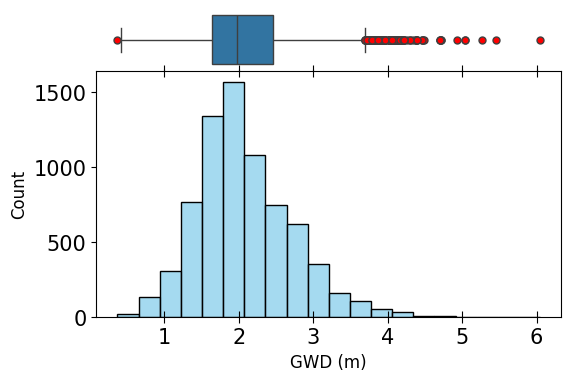

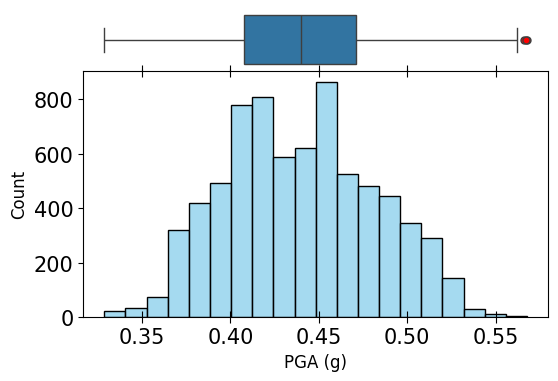

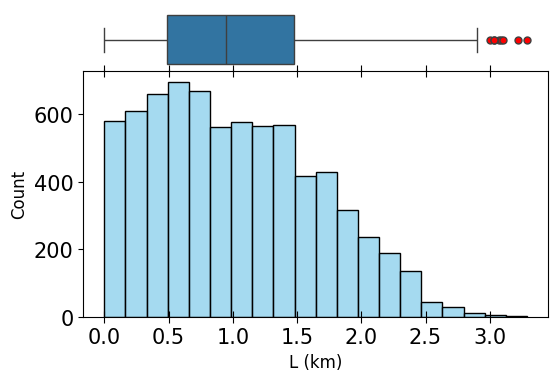

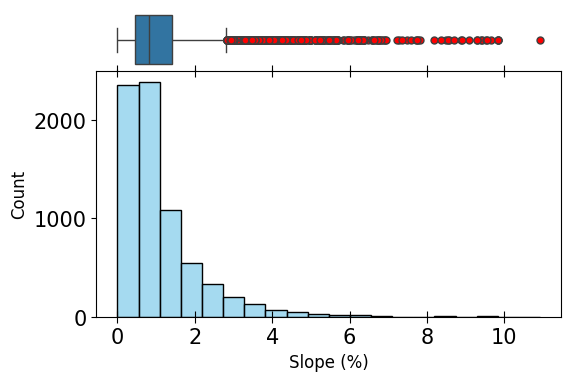

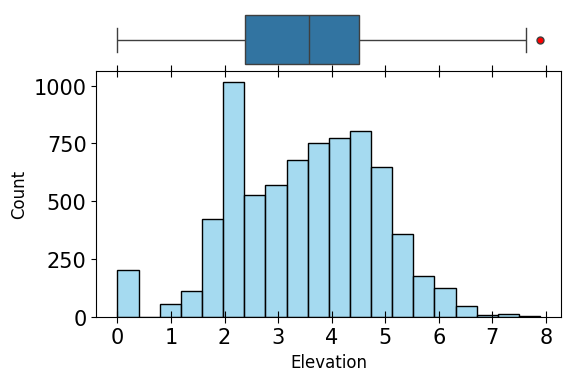

In [7]:
import matplotlib.gridspec as gridspec
basic_features = ['GWD (m)', 'PGA (g)', 'L (km)', 'Slope (%)', 'Elevation']
for feature in basic_features:
    # Create a grid of subplots using gridspec
    fig = plt.figure(figsize=(6, 4))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4])

    # Plot the histogram in the top subplot
    ax1 = plt.subplot(gs[0])
    sns.boxplot(data=X[feature], ax=ax1, flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}, orient='h')
    ax1.set_xlabel(None)
    ax1.set_ylabel(None)
    ax1.set_yticks([])  # Remove y-ticks
    # Remove the boundary around the subplots
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)


    # Plot the box plot in the bottom subplot
    ax2 = plt.subplot(gs[1], sharex = ax1)
    sns.histplot(data=X[feature], ax=ax2, color='skyblue', bins=20)
    # sns.histplot(data=X, x=feature, hue=y, ax=ax2, multiple="stack", bins=20)
    ax2.set_xlabel(feature, fontsize=12)  # Increase the font size of the x-axis label
    ax2.set_ylabel('Count', fontsize=12)  # Set the y-axis label to 'Count'
    # Show xticks on both top and bottom
    ax1.tick_params(axis='x', bottom=True, direction='inout')
    ax2.tick_params(axis='x', bottom=True, top=True, direction='inout', length=8, labelsize=15)
    ax2.tick_params(axis='y', labelsize=15)


    # remove vertical gap between subplots
    plt.subplots_adjust(hspace=.0)

    # Show the plot
    # plt.show()
    plt.savefig(f'{fig_path}/{feature}.png', dpi=300, bbox_inches='tight')

## train RF, XGB, and DT

In [8]:
# RF
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(max_depth=9, n_estimators=50, random_state=0)
best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, n_estimators=50, random_state=0)

In [9]:
# Define the parameter grid
param_grid = {
    'n_estimators': [25, 50, 100],
    'max_depth': [2, 4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3]
}

# Create an XGBoost classifier object
xgb_model = XGBClassifier(random_state=0)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score found: ", grid_search.best_score_)

# Get the best model
best_xgb = grid_search.best_estimator_


Best parameters found:  {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}
Best accuracy score found:  0.844013750456108


(0.0, 40.0)

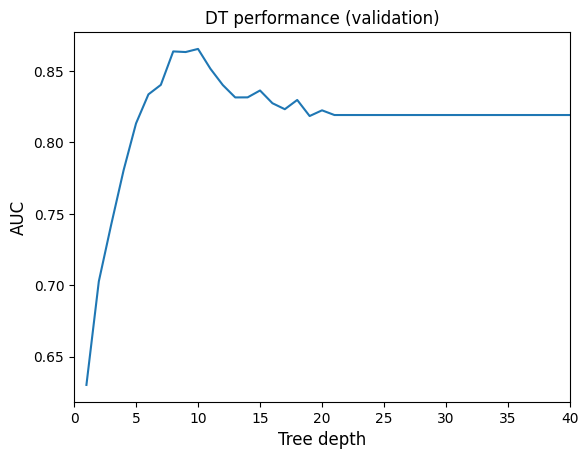

In [10]:
# train DT
from sklearn.tree import DecisionTreeClassifier
dt_auc = []
for depth in range(1,41):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=0)
    dt.fit(X_train,y_train)
    acc = dt.score(X_valid, y_valid)
    roc_auc = roc_auc_score(y_true=y_valid, y_score=dt.predict_proba(X_valid)[:,1])
    dt_auc.append(roc_auc)
plt.plot(np.arange(1,41), dt_auc)
plt.xlabel("Tree depth", fontsize=12)
plt.ylabel("AUC",fontsize=12)
plt.title("DT performance (validation)")
plt.xlim(0,40)

In [11]:
best_dt = DecisionTreeClassifier(max_depth=10, random_state=0).fit(X_train, y_train)
shallow_dt = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train)

### Performance of black-box models

In [12]:
def score_report(model, X, y, pos=1, format_str="{0:.3f}", valid=False):
  temp = pd.DataFrame(index=['Train','Valid','Test'],columns=['Acc','Precision','Recall','F1', 'ROC-AUC'])
  if valid:
    # only compute scores for valid tests and return scores
    y_pred = model.predict(X)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true=y,y_pred=y_pred, pos_label=pos, beta=1, average='binary')
    acc = model.score(X, y)
    roc_auc = roc_auc_score(y_true=y, y_score=model.predict_proba(X)[:,1])
    return {'Acc': acc, 'Precision': precision, 'Recall': recall, 'F1': f1, 'ROC-AUC': roc_auc}
  # plot for confusion matrices
  fig, axes = plt.subplots(1,3, figsize=(8,3))
  for dataset, y_true, row, ax in zip(X, y, temp.index, axes):
    y_pred = model.predict(dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true=y_true,y_pred=y_pred, pos_label=pos, beta=1, average='binary')
    acc = model.score(dataset, y_true)
    roc_auc = roc_auc_score(y_true=y_true, y_score=model.predict_proba(dataset)[:,1])
    # making score dataframe
    temp.loc[row]=np.array([acc, precision, recall, f1, roc_auc])
    # display confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred, display_labels=['No','Yes'], ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(row)
    plt.tight_layout()
  return temp.map(format_str.format)

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.701,0.715,0.464,0.563,0.768
Valid,0.705,0.738,0.464,0.570,0.781
Test,0.690,0.755,0.435,0.552,0.749


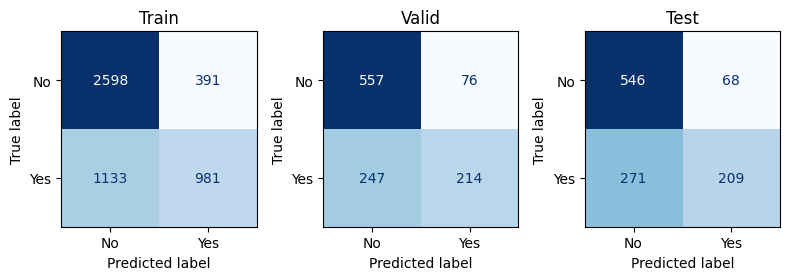

In [13]:
# Shallow DT
score_report(shallow_dt, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.911,0.909,0.871,0.890,0.974
Valid,0.813,0.799,0.742,0.769,0.865
Test,0.803,0.798,0.740,0.768,0.847


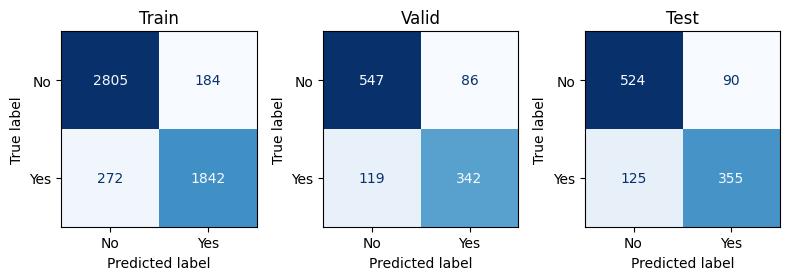

In [14]:
# Deep DT
score_report(best_dt, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.904,0.922,0.840,0.879,0.970
Valid,0.831,0.861,0.714,0.781,0.906
Test,0.815,0.860,0.692,0.767,0.894


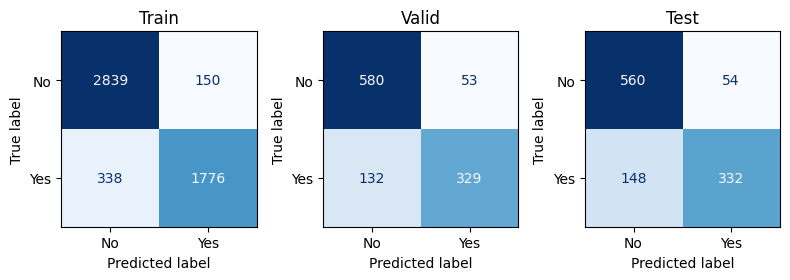

In [15]:
# RF
score_report(best_rf, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.963,0.967,0.944,0.955,0.994
Valid,0.842,0.848,0.761,0.802,0.917
Test,0.841,0.859,0.762,0.808,0.915


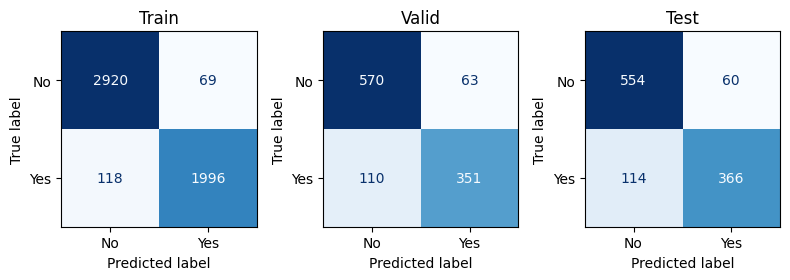

In [16]:
# XGB
score_report(best_xgb, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

## Training EBM

In [17]:
# train EBM
ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)

ExplainableBoostingClassifier()

In [18]:
ebm.get_params()

{'early_stopping_rounds': 50,
 'early_stopping_tolerance': 0.0001,
 'exclude': [],
 'feature_names': None,
 'feature_types': None,
 'greediness': 0.0,
 'inner_bags': 0,
 'interactions': 10,
 'learning_rate': 0.01,
 'max_bins': 256,
 'max_interaction_bins': 32,
 'max_leaves': 3,
 'max_rounds': 5000,
 'min_samples_leaf': 2,
 'n_jobs': -2,
 'objective': 'log_loss',
 'outer_bags': 8,
 'random_state': 42,
 'smoothing_rounds': 0,
 'validation_size': 0.15}

In [ ]:
# save ebm scores arrays in case we need to restore them after plotting
old_score = [score for score in ebm.term_scores_]
# function to restore ebm score arrays
def restore_ebm(scores):
  temp = [score for score in scores]
  ebm.term_scores_ = temp

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.883,0.886,0.824,0.853,0.951
Valid,0.804,0.800,0.714,0.755,0.874
Test,0.799,0.816,0.700,0.753,0.878


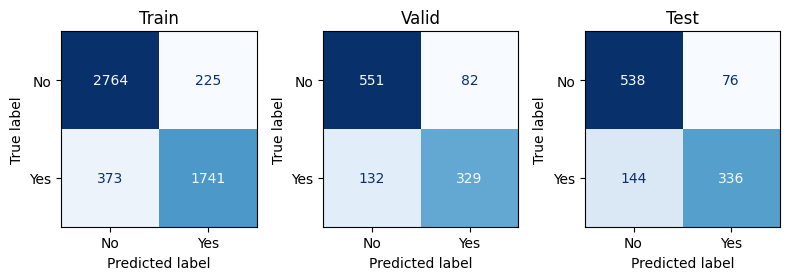

In [20]:
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

## Global explanation before modifying

In [21]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/13085403984/ -->

In [22]:
# local explanations for 5 test samples
ebm_local = ebm.explain_local(X=X_test.iloc[:5],y=y_test.iloc[:5])
show(ebm_local)

<!-- http://127.0.0.1:7001/13225752704/ -->

In [23]:
mask = (X_train['GWD (m)'] < 1.2) & (X_train['PGA (g)'] > 0.51)
y_train[mask].value_counts()

Target
False    33
True      2
Name: count, dtype: int64

In [24]:
mask = (X_train['GWD (m)'] < 1.2) & (X_train['PGA (g)'] > 0.51) & (X_train['L (km)'] < 0.5)
y_train[mask].value_counts()

Target
False    11
Name: count, dtype: int64

In [25]:
mask = (X_train['GWD (m)'] < 0.7)
y_train[mask].value_counts()

Target
False    19
True      2
Name: count, dtype: int64

In [26]:
for index in range(len(ebm.term_names_)):
  print(f'{index}\t{ebm.term_names_[index]}')

0	GWD (m)
1	Elevation
2	L (km)
3	Slope (%)
4	PGA (g)
5	GWD (m) & Elevation
6	GWD (m) & L (km)
7	GWD (m) & Slope (%)
8	GWD (m) & PGA (g)
9	Elevation & L (km)
10	Elevation & Slope (%)
11	Elevation & PGA (g)
12	L (km) & Slope (%)
13	L (km) & PGA (g)
14	Slope (%) & PGA (g)


In [27]:
gwd_index = 0
elevation_index = 1
l_index = 2
slope_index = 3
pga_index = 4
gwd_pga_index = 8
gwd_l_index = 6
l_pga_index = 13

In [28]:
def plot_score_curve(ebm, index, xlim=None, ylim=None, ):
  # plot score curve
  fig, ax = plt.subplots(figsize=(6,4))
  arr = np.copy(ebm.bins_[index][0])
  arr = np.insert(np.repeat(arr,2),0,ebm.feature_bounds_[index][0])
  arr = np.append(arr,ebm.feature_bounds_[index][1])
  ax.plot(arr, np.repeat(ebm.term_scores_[index][1:-1],2), c='blue')
  if xlim:
    ax.set_xlim(xlim)
  if ylim:
    ax.set_ylim(ylim)
  plt.xlabel(ebm.term_names_[index], fontsize=12)
  plt.ylabel(f'Score', fontsize=12)
  plt.title(f'Score curve: {ebm.term_names_[index]}', fontsize=12)
  plt.savefig(f'{fig_path}/score_curve_{ebm.term_names_[index]}.png', dpi=300, bbox_inches='tight')

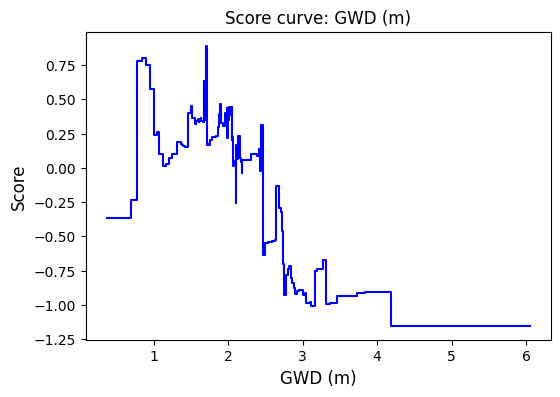

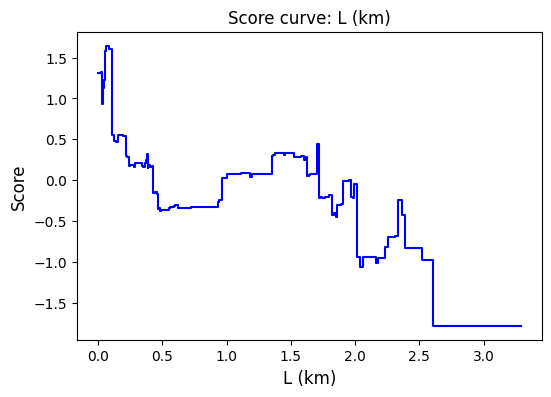

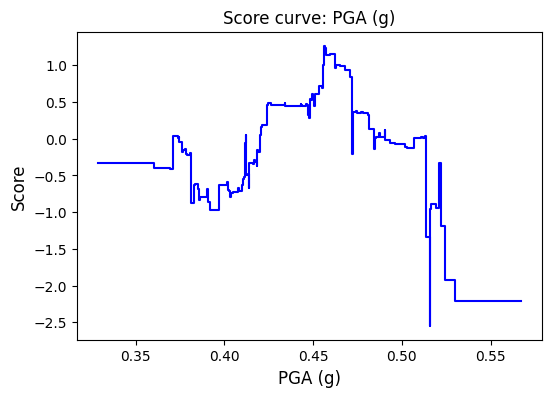

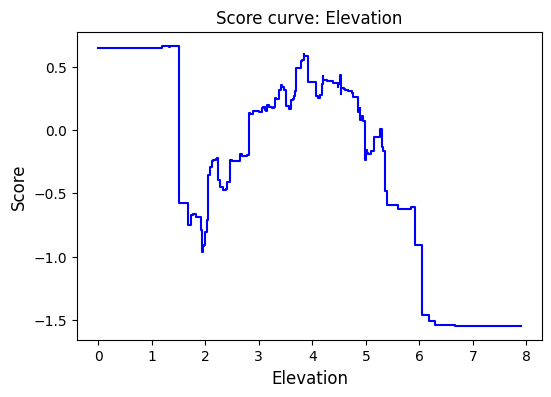

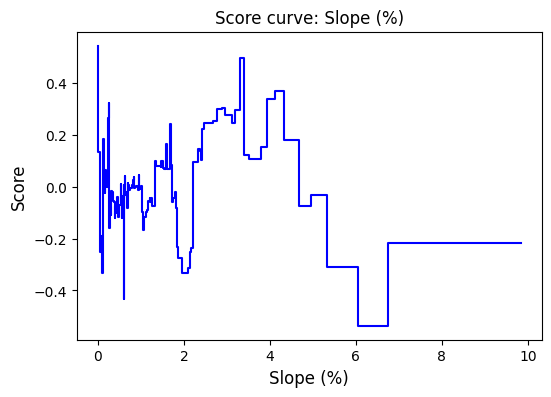

In [29]:
restore_ebm(old_score) # this is to make sure use the original ebm scores for plotting
plot_score_curve(ebm, gwd_index)
plot_score_curve(ebm, l_index)
plot_score_curve(ebm, pga_index)
plot_score_curve(ebm, elevation_index)
plot_score_curve(ebm, slope_index)

In [30]:
def plot_interaction_map(ebm, f_index):
    fig, ax = plt.subplots(figsize=(5,5))
    edges = []
    xs = []
    for index, i in zip(ebm.term_features_[f_index], range(2)):
        f_name = ebm.term_names_[index]
        # calculate bin centers
        x = (ebm.bins_[index][1][1:] + ebm.bins_[index][1][:-1])/2
        x = np.insert(x, 0, (ebm.feature_bounds_[index][0] + ebm.bins_[index][1][0])/2)
        x = np.append(x, (ebm.feature_bounds_[index][1] + ebm.bins_[index][1][-1])/2)
        xs.append(x)

        # copy bin edges
        edge = np.copy(ebm.bins_[index][1])
        # add max and min as the first and final bin edges
        edge = np.insert(edge, 0, ebm.feature_bounds_[index][0])
        edge = np.append(edge, ebm.feature_bounds_[index][1])
        edges.append(edge)

    #show original interaction map
    map = ebm.term_scores_[f_index][1:-1,1:-1] # excluding the 0 padding
    im2 = ax.pcolormesh(edges[1], edges[0], map, vmin=round(map.min()), vmax=round(map.max()))
    #im2 = ax.pcolormesh(edges[1], edges[0], old_map, vmin=-4, vmax=4)
    cbar = plt.colorbar(im2,fraction=0.046, pad=0.04)
    cbar.ax.set_title('Score')
    ax.set_xlabel(ebm.term_names_[ebm.term_features_[f_index][1]],fontsize=12)
    ax.set_ylabel(ebm.term_names_[ebm.term_features_[f_index][0]],fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12)
    aspect = (edges[1].max()-edges[1].min())/(edges[0].max()-edges[0].min())
    ax.set_aspect(aspect)
    ax.set_title('Interaction Map', fontsize=15)
    plt.savefig(f'{fig_path}/interaction_map_{ebm.term_names_[f_index]}.png', dpi=300, bbox_inches='tight')

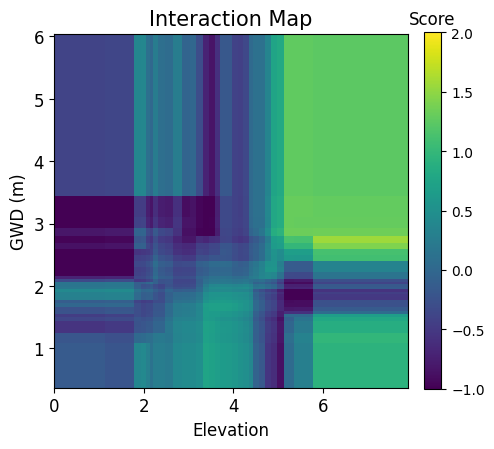

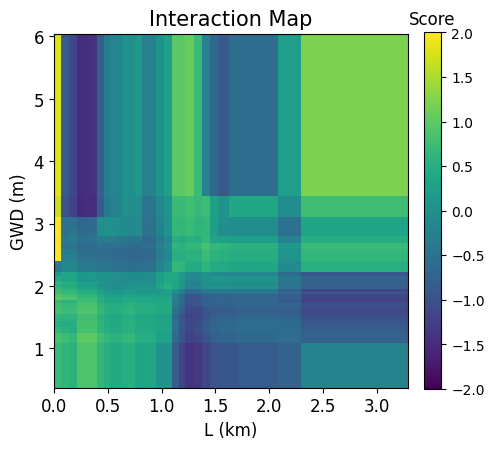

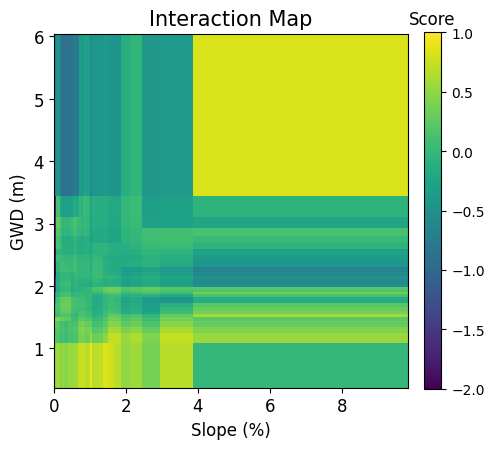

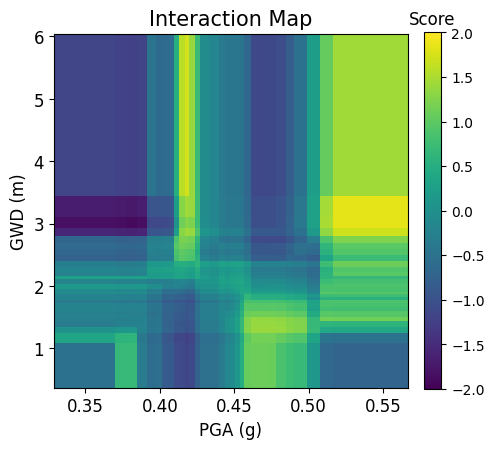

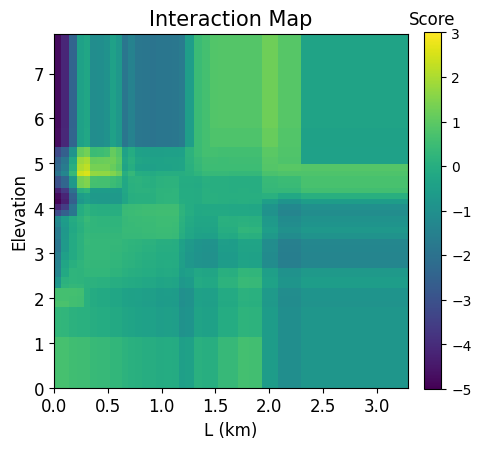

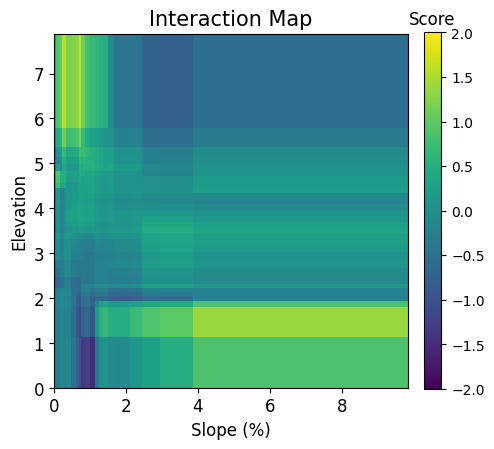

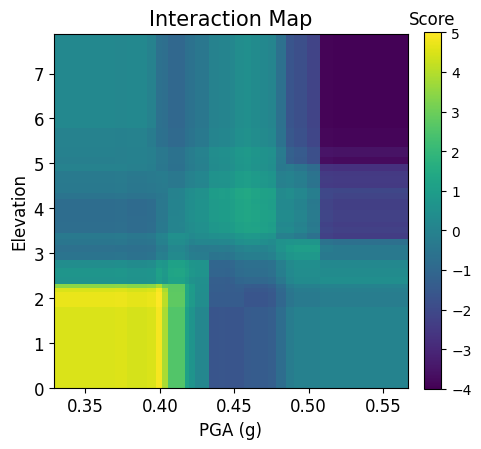

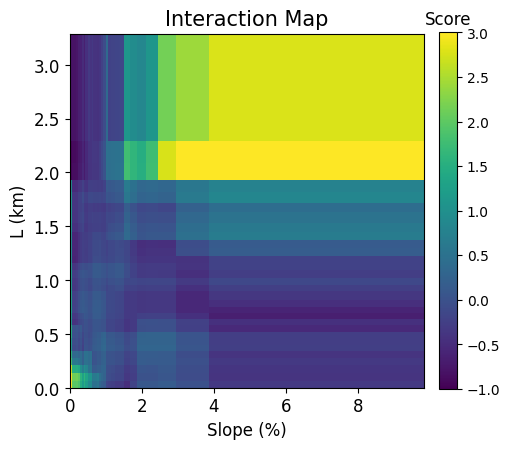

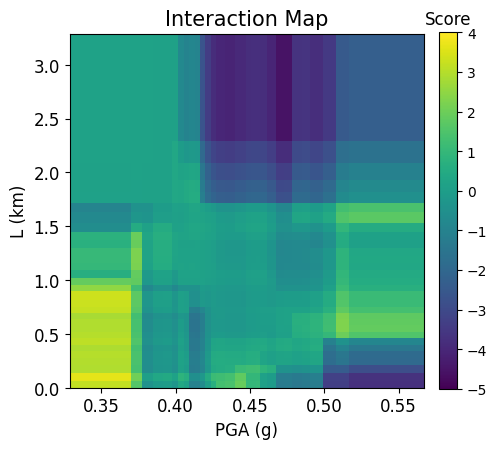

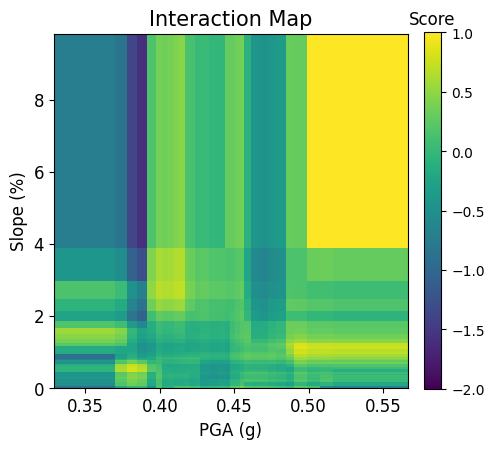

In [ ]:
for index in range(5,15): # 5th to 14th term are interaction terms
    plot_interaction_map(ebm, index)

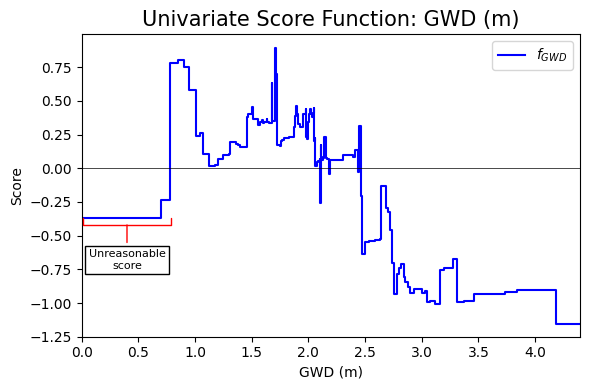

In [ ]:
# ==== showing the GWD score curve and highlight the unreasonable score ====

which = gwd_index # which term to plot
arr = np.copy(ebm.bins_[which][0])
arr = np.insert(np.repeat(arr,2),0,0)
arr = np.append(arr, arr.max()*1.05)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(arr, np.repeat(ebm.term_scores_[which][1:-1],2), c='blue', label=r'$f_{GWD}$')
ax.axhline(0,c='k', lw=0.5)
ax.set_xlim(0.3, arr.max())
ax.set_xlabel(ebm.term_names_[which])
ax.set_ylabel('Score')
ax.set_title(f'Univariate Score Function: {ebm.term_names_[which]}', fontsize=15)
# Draw a bracket on the plot
plt.annotate('Unreasonable\nscore', xy=(0.4, -0.4), xytext=(0.4, -0.6), xycoords='data',
             ha='center', va='top',fontsize=8,
             bbox=dict(boxstyle='square', fc='white', color='k'),
             arrowprops=dict(arrowstyle='-[, widthB=4.0, lengthB=0.6, angleB=0', lw=1, color='red'))
plt.xlim(0.)
plt.ylim(-1.25)
x_point = 1.15
y_point = 0.01
plt.legend()
plt.tight_layout()
plt.savefig(f'{fig_path}/score_curve_example_without_unphysics.png', dpi=300)

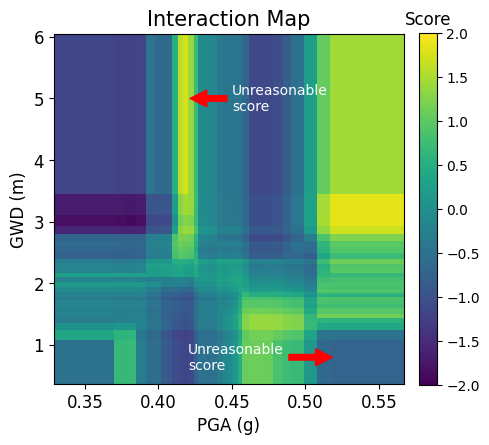

In [33]:
# ==== showing the GWD-PGA interaction map and highlight the unreasonable score ====

f_index = gwd_pga_index
fig, ax = plt.subplots(figsize=(5,5))
edges = []
xs = []
for index, i in zip(ebm.term_features_[f_index], range(2)):
    f_name = ebm.term_names_[index]
    # calculate bin centers
    x = (ebm.bins_[index][1][1:] + ebm.bins_[index][1][:-1])/2
    x = np.insert(x, 0, (X_train[f_name].min() + ebm.bins_[index][1][0])/2)
    x = np.append(x, (X_train[f_name].max() + ebm.bins_[index][1][-1])/2)
    xs.append(x)

    # copy bin edges
    edge = np.copy(ebm.bins_[index][1])
    # add max and min as the first and final bin edges
    edge = np.insert(edge, 0, ebm.feature_bounds_[index][0])
    edge = np.append(edge, ebm.feature_bounds_[index][1])
    edges.append(edge)

#show original interaction map
old_map = ebm.term_scores_[f_index][1:-1,1:-1] # excluding the 0 padding
im2 = ax.pcolormesh(edges[1], edges[0], old_map, vmin=round(old_map.min()), vmax=round(old_map.max()))
cbar = plt.colorbar(im2,fraction=0.046, pad=0.04)
cbar.ax.set_title('Score')
ax.set_xlabel(ebm.term_names_[ebm.term_features_[f_index][1]],fontsize=12)
ax.set_ylabel(ebm.term_names_[ebm.term_features_[f_index][0]],fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)
aspect = (edges[1].max()-edges[1].min())/(edges[0].max()-edges[0].min())
ax.set_aspect(aspect)
ax.set_title('Interaction Map', fontsize=15)
# annotate arrow
ax.annotate('Unreasonable\nscore', xy=(0.42, 5), xycoords='data',
            xytext=(0.45, 5), textcoords='data',
            va='center', ha='left', color='w',
            arrowprops=dict(facecolor='r',edgecolor='r', shrink=0.05))
ax.annotate('Unreasonable\nscore', xy=(0.52, 0.8), xycoords='data',
            xytext=(0.42, 0.8), textcoords='data',
            va='center', ha='left', color='w',
            arrowprops=dict(facecolor='r',edgecolor='r', shrink=0.05))

plt.tight_layout()
plt.savefig(f'{fig_path}/interaction_map_example_without_unphysics.png', dpi=300)

### Curve fitting

Next we are going to modify the score curve by fitting it with the selected points sampled from the original score curve.

In [34]:
# modify the score curve
def fitting(xp, fp, f_index, replace=False, show=True):
  f_name = ebm.feature_names_in_[ebm.term_features_[f_index][0]]
  # copy bins array
  arr = np.copy(ebm.bins_[f_index][0])
  arr = np.insert(np.repeat(arr,2),0,0)
  arr = np.append(arr, arr.max()*1.05)
  # new curve
  arr2 = np.copy(ebm.bins_[f_index][0])
  x = (arr2[:-1] + arr2[1:])/2
  score = np.interp(x, xp, fp)
  score = np.insert(score, 0, fp[0])
  score = np.append(score, fp[-1])
  arr2 = np.insert(np.repeat(arr2,2),0,0)
  arr2 = np.append(arr2, arr2.max()*1.05)
  
  #ax.tight_layout()
  # fit the shape
  ebm_score = np.insert(score,0,0)
  ebm_score = np.append(ebm_score,0)
  
  if show:
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(arr, np.repeat(ebm.term_scores_[f_index][1:-1],2), c='blue', lw=1, label='Original curve')
    ax.plot(arr2, np.repeat(score,2), 'red', linestyle='--', label='Modified curve')
    # add a horizontal line
    ax.axhline(0,c='k', lw=0.5)
    ax.set_xlim(0, arr.max())
    ax.set_xlabel(f_name)
    ax.set_ylabel('Score')
    ax.set_title(f'Score curve: {f_name}', fontsize=15)
    ax.legend()
    
  if replace:
    # print(f'{f_name} score curve replaced')
    ebm.term_scores_[f_index] = ebm_score
  if show:
    return ax
  

In [35]:
restore_ebm(old_score) # To make sure we are use the original ebm scores for plotting

Fitting sigmoid-like function

$f(x) = \frac{{c}}{{1+e^{{-a(x-b)}}}} + d$


Fitting sigmoid function: $f(x) = \\frac{{c}}{{1+e^{{-a(x-b)}}}} + d$
Optimized parameters:
a = 73.481
b = 0.420
c = 2.169
d = -1.160


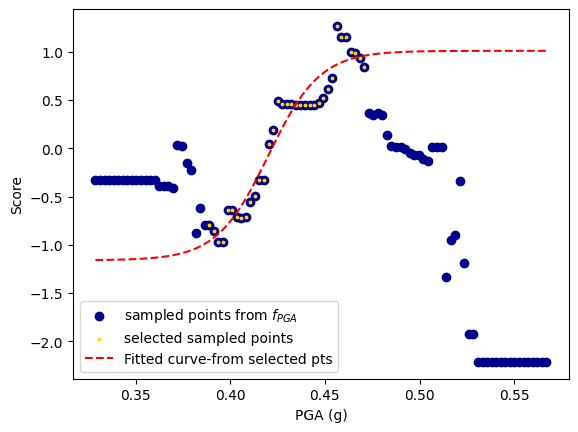

In [ ]:
from scipy.optimize import curve_fit
plt.figure()
# sampled points from PGA score curve
n_sample = 100
fake_data = np.zeros((n_sample,5)) # create n data points with 5 features
pga_sample_x = np.linspace(X_train['PGA (g)'].min(), X_train['PGA (g)'].max(), num=n_sample) # sample points
fake_data[:,pga_index] = pga_sample_x
pga_sample_y = ebm.eval_terms(fake_data)[:,pga_index]
# select points from sampled points
indexes = np.arange(25,len(pga_sample_x)-40)
pga_select_x = pga_sample_x[indexes]
pga_select_y = pga_sample_y[indexes]
# plot sampled points
plt.scatter(pga_sample_x, pga_sample_y, label=r'sampled points from $f_{PGA}$', color='darkblue')
plt.scatter(pga_select_x, pga_select_y, label=f'selected sampled points', color='gold',s=3)

# new sampled points for plotting
xp_pga = pga_sample_x

# sigmoid function optimization
def model_func(x, a, b, c, d):
    return c/(1+np.exp(-a*(x-b)))+d
# Perform the curve fitting
popt_select, pcov = curve_fit(model_func, pga_select_x, pga_select_y,)
# popt contains the best fit parameters: a, b, c
a, b, c, d = popt_select
print(f"Optimized parameters:\na = {a:.3f}\nb = {b:.3f}\nc = {c:.3f}\nd = {d:.3f}")
# Generate fitted data
fp_pga = model_func(xp_pga, *popt_select)
plt.plot(xp_pga, fp_pga,'r--', label='Fitted curve-from selected pts')

plt.xlabel('PGA (g)')
plt.ylabel('Score')
plt.legend()
plt.show()

Optimized parameters:
a = -1.260
b = 0.000
c = 5.372
d = -1.792


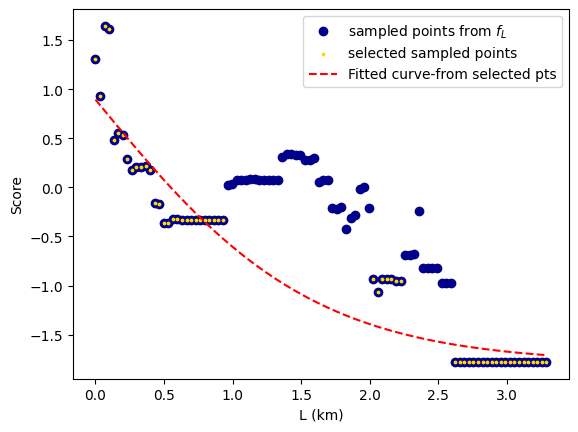

In [40]:
plt.figure()
# sampled points from PGA score curve
n_sample = 100
fake_data = np.zeros((n_sample,5)) # create n data points with 5 features
l_sample_x = np.linspace(X_train['L (km)'].min(), X_train['L (km)'].max(), num=n_sample) # sample points
fake_data[:,l_index] = l_sample_x
l_sample_y = ebm.eval_terms(fake_data)[:,l_index]
# select points from sampled points
indexes = np.concatenate((np.arange(0,29),np.arange(61,68),np.arange(len(l_sample_x)-21,len(l_sample_x))))
l_select_x = l_sample_x[indexes]
l_select_y = l_sample_y[indexes]
# plot sampled points
plt.scatter(l_sample_x, l_sample_y, label=r'sampled points from $f_{L}$', color='darkblue')
plt.scatter(l_select_x, l_select_y, label=f'selected sampled points', color='gold',s=3)

# new sampled points for plotting
xp_l = l_sample_x

# Perform the curve fitting
popt_select, pcov = curve_fit(model_func, l_select_x, l_select_y, bounds=([-np.inf,0,-np.inf,-np.inf], [0, np.inf, np.inf, np.inf]))
# popt contains the best fit parameters: a, b, c
a, b, c, d = popt_select
print(f"Optimized parameters:\na = {a:.3f}\nb = {b:.3f}\nc = {c:.3f}\nd = {d:.3f}")

# Generate fitted data
fp_l = model_func(xp_l, *popt_select)
plt.plot(xp_l, fp_l,'r--', label='Fitted curve-from selected pts')

plt.xlabel('L (km)')
plt.ylabel('Score')
plt.legend()
plt.show()

Optimized parameters: a = -2.269427290405277, b = 2.3999253034945833, c = 1.853817690031361, d = -1.1240516213026226


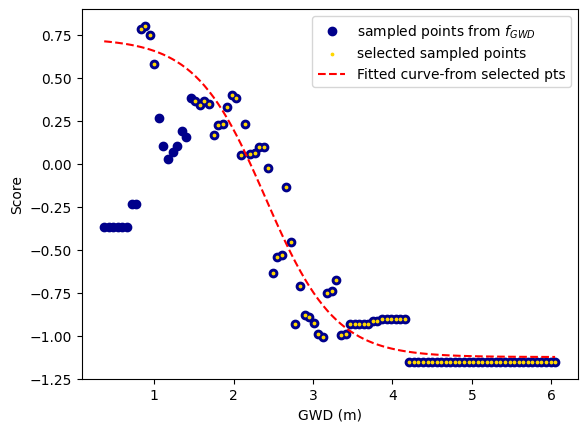

In [42]:
plt.figure()
# sampled points from PGA score curve
n_sample = 100
fake_data = np.zeros((n_sample,5)) # create n data points with 5 features
gwd_sample_x = np.linspace(X_train['GWD (m)'].min(), X_train['GWD (m)'].max(), num=n_sample) # sample points
fake_data[:,gwd_index] = gwd_sample_x
gwd_sample_y = ebm.eval_terms(fake_data)[:,gwd_index]
# select points from sampled points
indexes = np.concatenate((np.arange(8,12),np.arange(20,len(gwd_sample_x))))
gwd_select_x = gwd_sample_x[indexes]
gwd_select_y = gwd_sample_y[indexes]
# plot sampled points
plt.scatter(gwd_sample_x, gwd_sample_y, label=r'sampled points from $f_{GWD}$', color='darkblue')
plt.scatter(gwd_select_x, gwd_select_y, label=f'selected sampled points', color='gold',s=3)

# new sampled points for plotting
xp_gwd = gwd_sample_x

# sigmoid function optimization
def model_func(x, a, b, c, d):
    return c/(1+np.exp(-a*(x-b)))+d
# Perform the curve fitting
popt_select, pcov = curve_fit(model_func, gwd_select_x, gwd_select_y, bounds=([-np.inf,-np.inf,-np.inf,-np.inf], [0, np.inf, np.inf, np.inf]))
# popt contains the best fit parameters: a, b, c
a, b, c, d = popt_select
print(f"Optimized parameters: a = {a}, b = {b}, c = {c}, d = {d}")
# Generate fitted data
fp_gwd = model_func(xp_gwd, *popt_select)
plt.plot(xp_gwd, fp_gwd,'r--', label='Fitted curve-from selected pts')

plt.xlabel('GWD (m)')
plt.ylabel('Score')
plt.legend()
plt.show()

### Modify curve

Once we are satisfied with the fitted curve, we are going to replace the original function with the fitted one.

In [43]:
restore_ebm(old_score) # To make sure we are use the original ebm scores

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.880,0.881,0.822,0.851,0.948
Valid,0.802,0.788,0.725,0.755,0.873
Test,0.800,0.813,0.706,0.756,0.875


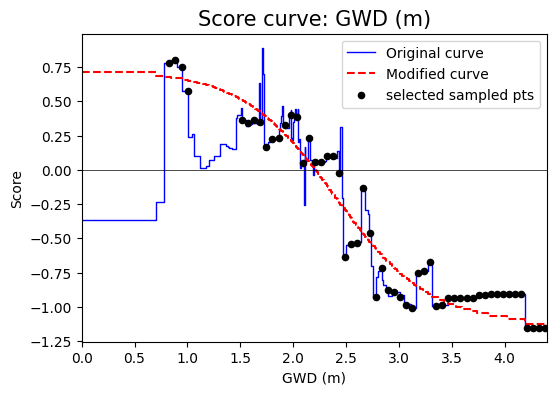

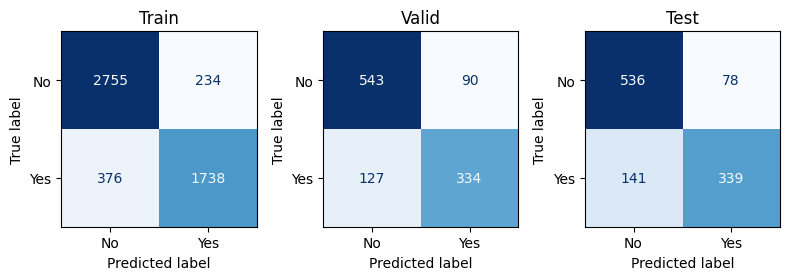

In [44]:
# GWD
ax = fitting(xp_gwd,fp_gwd,gwd_index, replace=True)
# plt.scatter(gwd_sample_x, gwd_sample_y, label=r'sampled pts from $f_{GWD}$', color='k',s=20, facecolor='none', zorder=10)
plt.scatter(gwd_select_x, gwd_select_y, label=f'selected sampled pts', color='k',s=20, zorder=20)
plt.legend()
plt.savefig(f'{fig_path}/modify-gwd.png',dpi=300)
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.868,0.894,0.773,0.829,0.944
Valid,0.802,0.816,0.683,0.744,0.873
Test,0.782,0.817,0.650,0.724,0.871


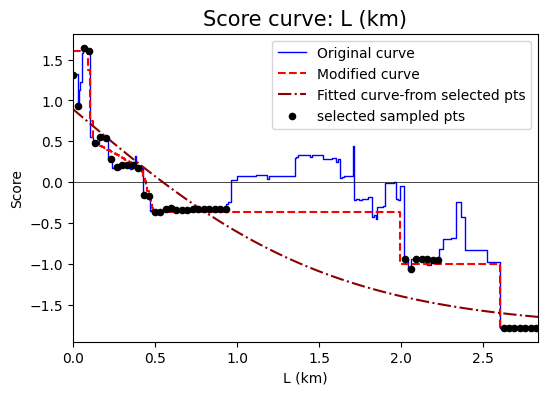

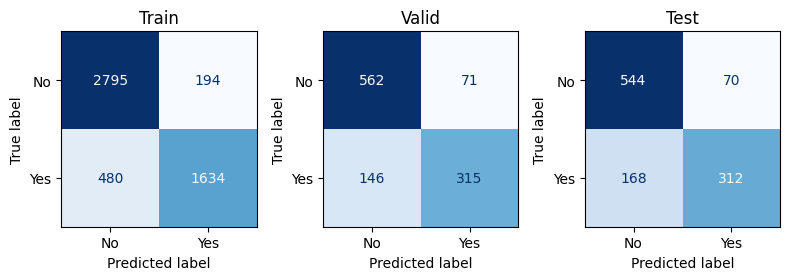

In [ ]:
# L (km)
# mannually selected because we think the L score curve is not in sigmoid shape
xp_l_man = [0.093, 0.12, 0.42, 0.49, 1.99, 2, 2.599, 2.6]
fp_l_man = [1.61, 0.5, 0.17, -0.36, -0.36, -1,-1, -1.77]
ax = fitting(xp_l_man,fp_l_man,l_index, replace=True)
plt.plot(xp_l, fp_l,'-.', label='Fitted curve-from selected pts', color='darkred')
plt.scatter(l_select_x, l_select_y, label=f'selected sampled pts', color='k',s=20, zorder=20)
plt.legend()
plt.savefig(f'{fig_path}/modify-l.png',dpi=300)
# after applying domain knowledge
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.837,0.828,0.765,0.795,0.917
Valid,0.781,0.773,0.679,0.723,0.854
Test,0.776,0.780,0.681,0.727,0.850


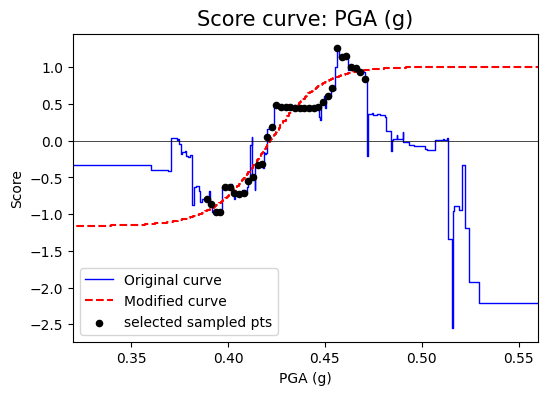

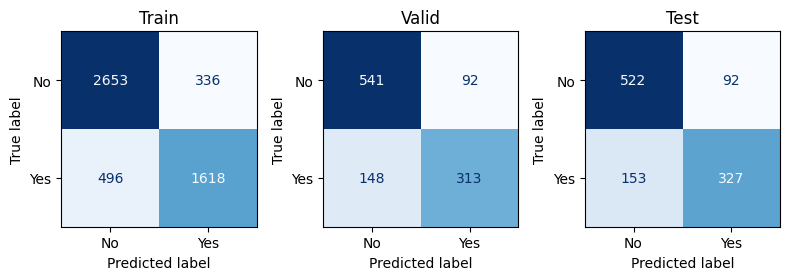

In [46]:
# PGA (g)
ax = fitting(xp_pga,fp_pga,pga_index,replace=True)
# plt.scatter(pga_sample_x, pga_sample_y, label=r'sampled pts from $f_{PGA}$', color='k',s=20, facecolor='none', zorder=10)
plt.scatter(pga_select_x, pga_select_y, label=f'selected sampled pts', color='k',s=20, zorder=20)
plt.legend()
plt.xlim(0.32)
plt.savefig(f'{fig_path}/modify-pga.png',dpi=300)
# after applying domain knowledge
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

In [47]:
# save the score after modification of univariate score curves for later restoration
intermediate_score = [score for score in ebm.term_scores_]

### Synthesize interaction map

We are going to synthesize the interaction map with the modified univariate function from the previous section.

In [48]:
from matplotlib import cm
from matplotlib.colors import Normalize

def plot_ebm_interaction_wireframe(x_edges, y_edges, scores, elev=30, azim=135, vmin=-2, vmax=2, swap_xy=False, lw=2):

    # Set up colormap
    cmap = cm.viridis
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    def draw_top_face(ax, x0, x1, y0, y1, z):
        corners = [
            (x0, y0, z), (x1, y0, z),
            (x1, y1, z), (x0, y1, z),
            (x0, y0, z)
        ]
        xs, ys, zs = zip(*corners)
        ax.plot3D(xs, ys, zs, color=cmap(norm(z)), linewidth=lw)

    def draw_vertical_edge(ax, x, y, z1, z2):
        mid_z = (z1 + z2) / 2
        ax.plot3D([x, x], [y, y], [z1, z2], color=cmap(norm(mid_z)), linewidth=lw)

    # Create plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    nx, ny = len(x_edges) - 1, len(y_edges) - 1
    for i in range(nx):
        for j in range(ny):
            x0, x1 = x_edges[i], x_edges[i+1]
            y0, y1 = y_edges[j], y_edges[j+1]
            z = scores[i, j]

            draw_top_face(ax, x0, x1, y0, y1, z)

            if i + 1 < nx:
                z2 = scores[i+1, j]
                draw_vertical_edge(ax, x1, y0, z, z2)
                draw_vertical_edge(ax, x1, y1, z, z2)

            if j + 1 < ny:
                z2 = scores[i, j+1]
                draw_vertical_edge(ax, x0, y1, z, z2)
                draw_vertical_edge(ax, x1, y1, z, z2)

    # Axes and view

    ax.set_zlabel('Score')
    ax.view_init(elev=elev, azim=azim)

    # mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    # fig.colorbar(mappable, ax=ax, shrink=0.5, label='Score')

    return ax


In [49]:
def sythesize(xp1, fp1, xp2, fp2, f_index, vmin=-2, vmax=2):
  fig, ax = plt.subplots(3,2,figsize=(8,9))
  edges = []
  new_scores = []
  xs = []
  f_names = [ebm.term_names_[ebm.term_features_[f_index][0]],ebm.term_names_[ebm.term_features_[f_index][1]]]
  # clean up names, replace text within parentheses with empty string
  clean_f_names = [re.sub(r'\s*\(.*?\)\s*', '', name) for name in f_names]
  for index, xp, fp, i in zip(ebm.term_features_[f_index], [xp1, xp2], [fp1, fp2], range(2)):
    f_name = ebm.term_names_[index]
    # calculate bin centers
    x = (ebm.bins_[index][1][1:] + ebm.bins_[index][1][:-1])/2
    x = np.insert(x, 0, (X_train[f_name].min() + ebm.bins_[index][1][0])/2)
    x = np.append(x, (X_train[f_name].max() + ebm.bins_[index][1][-1])/2)
    xs.append(x)
    new_scores.append(np.interp(x, xp, fp))

    # copy bin edges
    edge = np.copy(ebm.bins_[index][1])
    # add max and min as the first and final bin edges
    edge = np.insert(edge, 0, ebm.feature_bounds_[index][0])
    edge = np.append(edge, ebm.feature_bounds_[index][1])
    edges.append(edge)

  for i in range(2):
    #feature 1 is on y axis
    f_name = ebm.term_names_[ebm.term_features_[f_index][i]]
    # extend curve as constant value for plotting
    x_data = np.insert(xs[i], 0, (X_train[f_name].min()))
    x_data = np.append(x_data, (X_train[f_name].max()))
    y_data = np.insert(new_scores[i], 0, new_scores[i][0])
    y_data = np.append(y_data, new_scores[i][-1])
    ax[i,0].step(edges[i], np.append(new_scores[i], new_scores[i][-1]), where='post')
    # ax[i,0].plot(edges[i][:-1],new_scores[i])

    ax[i,0].set_xlabel(f_name)
    ax[i,0].set_ylabel('Scores')
    if i == 0:
      im = ax[i,1].pcolormesh(np.arange(31), edges[i], np.tile(new_scores[i].reshape(-1,1),30), vmin=vmin, vmax=vmax)
      ax[i,1].set_ylabel(f_name)
      ax[i,1].set_xlabel('bins')
      aspect = 30/(edges[i].max()-edges[i].min())
    else:
      im = ax[i,1].pcolormesh(edges[i], np.arange(31), np.tile(new_scores[i],[30,1]), vmin=vmin, vmax=vmax)
      ax[i,1].set_ylabel('bins')
      ax[i,1].set_xlabel(f_name)
      aspect = (edges[i].max()-edges[i].min())/30
    ax[i,1].set_aspect(aspect)
    plt.colorbar(im, ax=ax[i,1])


  #show original interaction map
  old_map = ebm.term_scores_[f_index][1:-1,1:-1] # excluding the 0 padding
  im2 = ax[2,0].pcolormesh(edges[1], edges[0], old_map, vmin=vmin, vmax=vmax)
  plt.colorbar(im2, ax=ax[2,0])
  ax[2,0].set_xlabel(ebm.term_names_[ebm.term_features_[f_index][1]])
  ax[2,0].set_ylabel(ebm.term_names_[ebm.term_features_[f_index][0]])
  aspect = (edges[1].max()-edges[1].min())/(edges[0].max()-edges[0].min())
  ax[2,0].set_aspect(aspect)
  title = rf'$f_{{{clean_f_names[0]},{clean_f_names[1]}}}$'
  ax[2,0].set_title(title, fontsize=15)

  # synthesize the map
  synth_map = np.tile(new_scores[0].reshape(-1,1),30) + np.tile(new_scores[1],[30,1])
  # rescale the synthectic map
  print('interaction map scale')
  print(ebm.term_scores_[f_index].max().round(4), ebm.term_scores_[f_index].min().round(4))
  print('synthectic scale before rescaling')
  print(synth_map.max().round(4), synth_map.min().round(4))
  # rescale synthetic map
  map_std = (synth_map-synth_map.min())/(synth_map.max()-synth_map.min())
  map_scaled = map_std*(old_map.max() - old_map.min()) + old_map.min()
  print('synthectic scale after rescaling')
  print(map_scaled.max().round(4), map_scaled.min().round(4))

  # show rescaled synthetic map
  im3 = ax[2,1].pcolormesh(edges[1], edges[0], map_scaled, vmin=vmin, vmax=vmax)
  plt.colorbar(im3, ax=ax[2,1])
  ax[2,1].set_xlabel(ebm.term_names_[ebm.term_features_[f_index][1]])
  ax[2,1].set_ylabel(ebm.term_names_[ebm.term_features_[f_index][0]])
  title = rf'$f^{{\mathrm{{syn,res}}}}_{{{clean_f_names[0]},{clean_f_names[1]}}}$'
  ax[2,1].set_title(title, fontsize=15)
  ax[2,1].set_aspect(aspect)
  plt.tight_layout()
  plt.savefig(f'{fig_path}/test.png', dpi=300)
  return map_scaled, edges

interaction map scale
1.8405 -1.896
synthectic scale before rescaling
1.6981 -2.2632
synthectic scale after rescaling
1.8405 -1.896


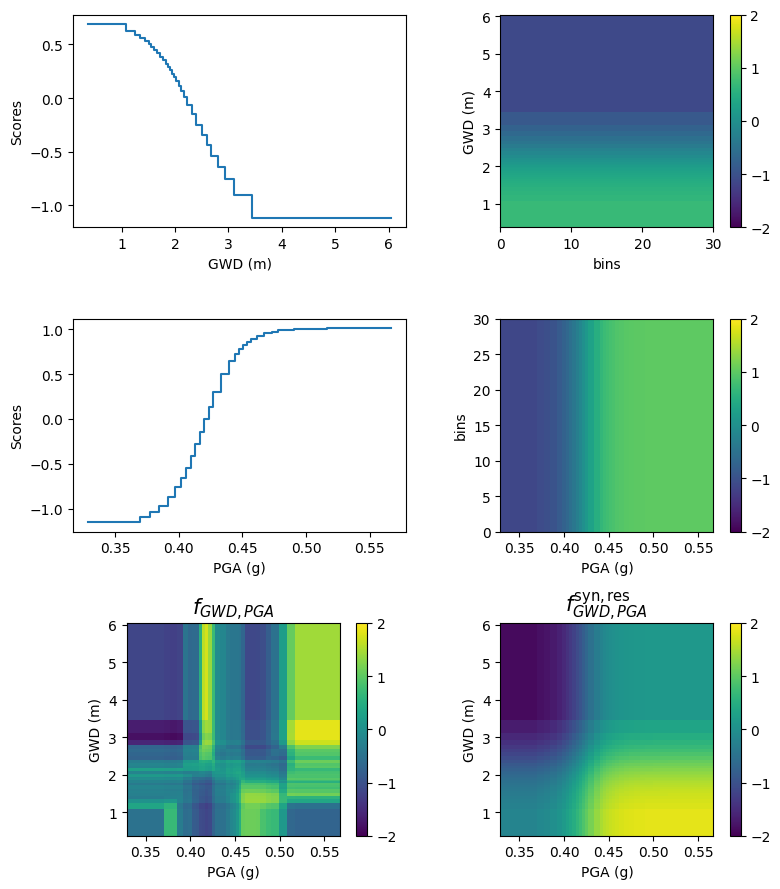

In [50]:
# GWD and PGA
gwd_pga_map, gwd_pga_edges = sythesize(xp_gwd,fp_gwd,xp_pga,fp_pga,gwd_pga_index)

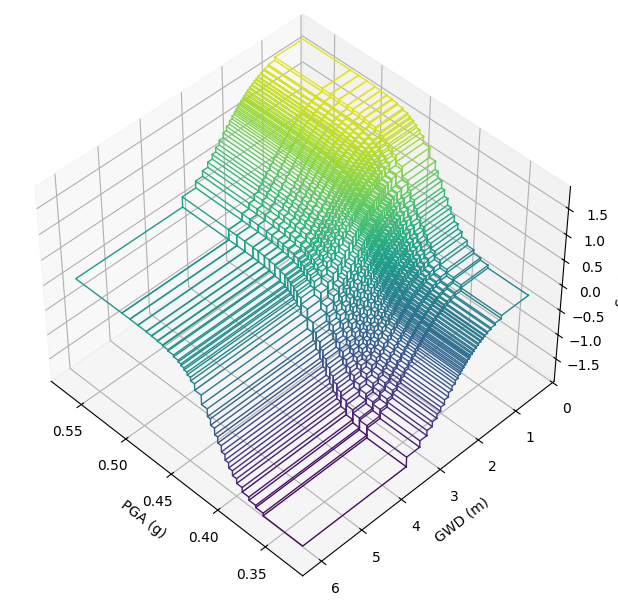

In [51]:
ax = plot_ebm_interaction_wireframe(gwd_pga_edges[1], gwd_pga_edges[0], gwd_pga_map.T, elev=45, azim=135, vmin=-2, vmax=2, lw=1)
ax.set_xlabel('PGA (g)')
ax.set_ylabel('GWD (m)')
plt.tight_layout()
plt.savefig(f'{fig_path}/gwd_pga_wireframe.png', dpi=300)

interaction map scale
2.2845 -1.5231
synthectic scale before rescaling
2.2991 -2.885
synthectic scale after rescaling
2.2845 -1.5231


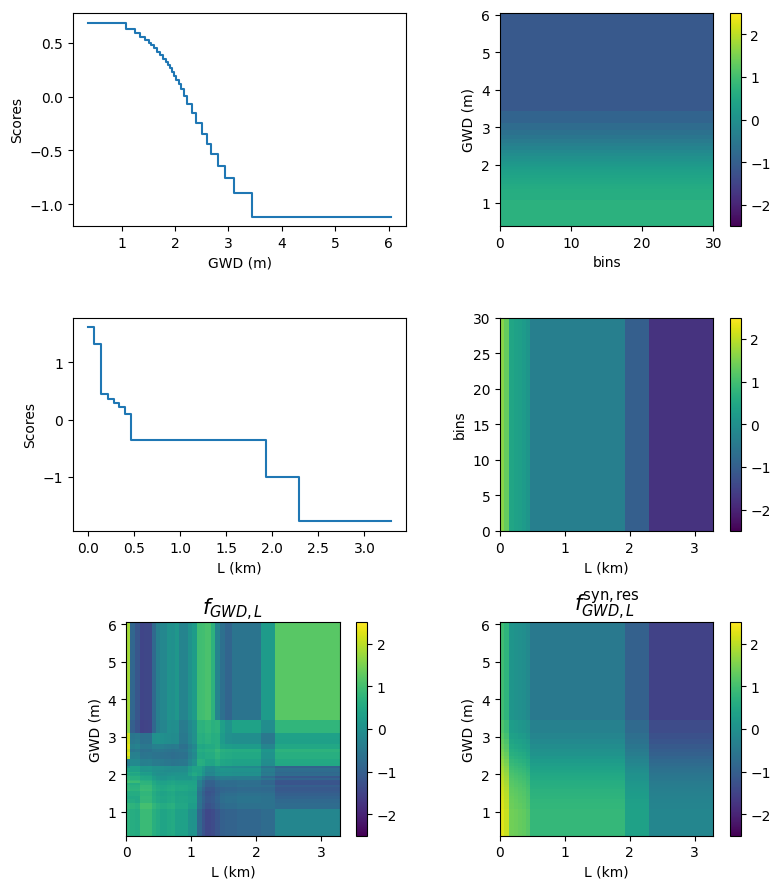

In [52]:
# GWD and L
gwd_l_map, gwd_l_edges =sythesize(xp_gwd,fp_gwd,xp_l_man,fp_l_man,gwd_l_index,vmin=-2.5, vmax=2.5)

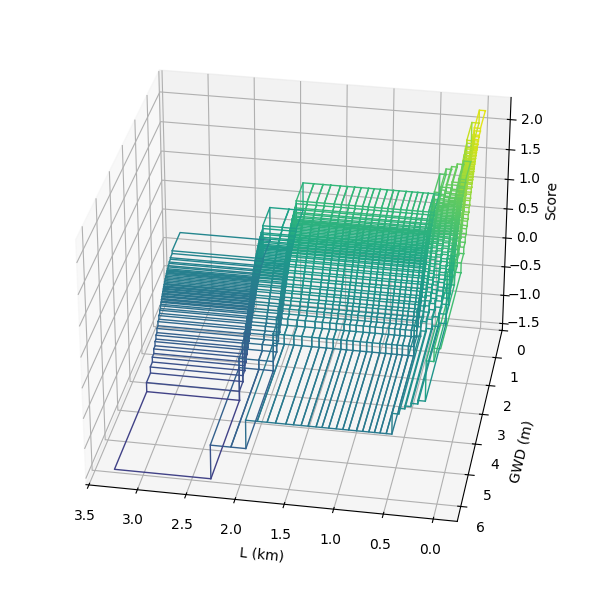

In [53]:
ax = plot_ebm_interaction_wireframe(gwd_l_edges[1], gwd_l_edges[0], gwd_l_map.T, elev=30, azim=100, vmin=-2.5, vmax=2.5, lw=1)
ax.set_xlabel('L (km)')
ax.set_ylabel('GWD (m)')
plt.tight_layout()
plt.show()

interaction map scale
3.6164 -4.5694
synthectic scale before rescaling
2.619 -2.9181
synthectic scale after rescaling
3.6164 -4.5694


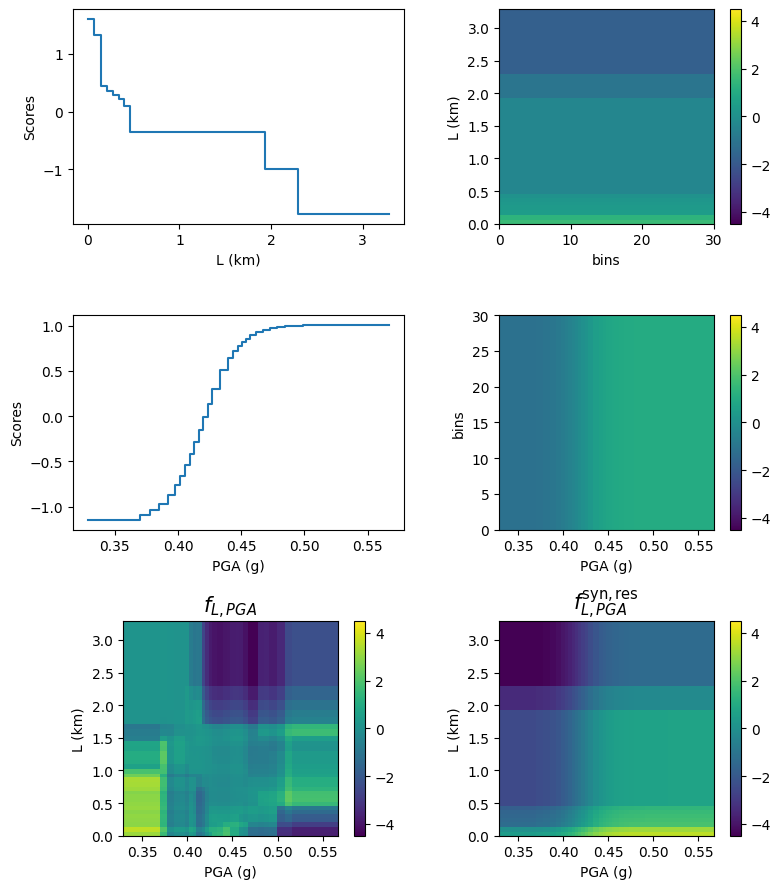

In [54]:
# L and PGA
l_pga_map, l_pga_edges = sythesize(xp_l_man,fp_l_man,xp_pga,fp_pga,l_pga_index, vmin=-4.5, vmax=4.5)

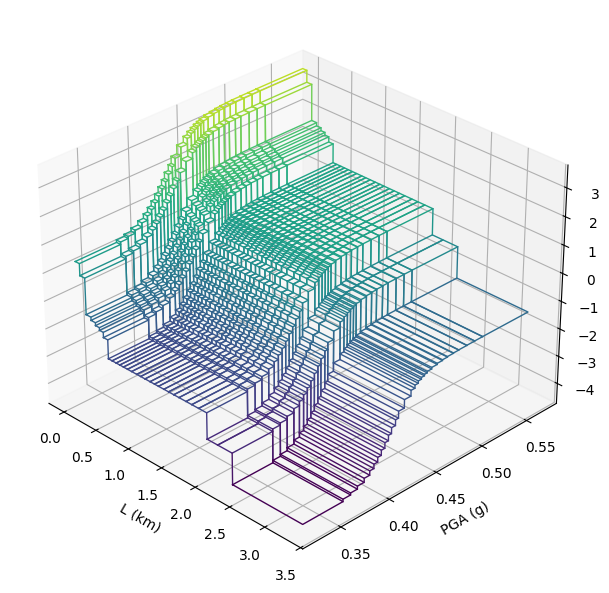

In [55]:
ax = plot_ebm_interaction_wireframe(l_pga_edges[0], l_pga_edges[1], l_pga_map, elev=30, azim=-45, vmin=-4.5, vmax=4.5, lw=1)
ax.set_xlabel('L (km)')
ax.set_ylabel('PGA (g)')
plt.tight_layout()
plt.show()

### mask for synthetic map

We don't want to replace the whole interaction map with the synthesized one. We only replace the region that is very different from the synthesized map with a threshold.

In [56]:
restore_ebm(intermediate_score) # To make sure the interaction maps are not modified

In [57]:
import re
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
def mask_map_func(new_map, edges, f_index, threshold=0.35, check='rng', legend_loc=None, vmin=-2, vmax=2, show=True):
  old_map = ebm.term_scores_[f_index][1:-1,1:-1]
  diff_map = abs(old_map - new_map) # absolute difference
  superscription = 'rel' if check == 'rel' else 'rng'
  if check == 'rel':
    diff_map = abs(diff_map/old_map) # relative difference
  else:
    diff_map = diff_map/(old_map.max()-old_map.min())
  mask_map = np.copy(old_map)
  replaced_ratio = (diff_map>threshold).sum()/900
  mask_map[diff_map>threshold] = new_map[diff_map>threshold]
  if show:
    realscale = False
    print(f'replaced ratio: {replaced_ratio*100:.2f}%')
    
    fig, ax = plt.subplots(1,5,figsize=(12,4),gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.05]})
    # aspect = (edges[1].max()-edges[1].min())/(edges[0].max()-edges[0].min())
    f_names = [ebm.term_names_[ebm.term_features_[f_index][0]],ebm.term_names_[ebm.term_features_[f_index][1]]]
    # clean up names, replace text within parentheses with empty string
    clean_f_names = [re.sub(r'\s*\(.*?\)\s*', '', name) for name in f_names]
    titles = [rf"$\Delta^{{\mathrm{{{superscription}}}}} > {threshold*100:.0f}\%?$",
        rf'$f_{{\mathrm{{{clean_f_names[0]},{clean_f_names[1]}}}}}$',
        rf'$f_{{\mathrm{{{clean_f_names[0]},{clean_f_names[1]}}}}}^{{\mathrm{{syn, res}}}}$',
        rf'$f_{{\mathrm{{{clean_f_names[0]},{clean_f_names[1]}}}}}^{{\prime}}$']
    maps = [diff_map>threshold, old_map, new_map, mask_map]
    for i in range(4):
      if i==0:
        if realscale:
          im = ax[i].pcolormesh(edges[1], edges[0], maps[i], cmap='Greys') # x and y are in real scale
        else:
          # x and y are indexes of bins, not in real scale, so aspect ratio is 1:1
          im = ax[i].pcolormesh(np.arange(31), np.arange(31), maps[i], cmap='Greys')
        ax[i].set_ylabel(f_names[0], fontsize=12)
      else:
        if realscale:
          im = ax[i].pcolormesh(edges[1], edges[0], maps[i], vmin=vmin, vmax=vmax)
        else:
          im = ax[i].pcolormesh(np.arange(31), np.arange(31), maps[i], vmin=vmin, vmax=vmax)
          ax[i].set_yticklabels([])
          ax[i].tick_params(axis="y", which="both", direction="inout",length=8)
      ax[i].axis('tight')
      ax[i].set_xlabel(f_names[1], fontsize=14)
      ax[i].tick_params(axis='both', which='major', labelsize=12) # set tick label size
      ax[i].set_title(titles[i], fontsize=18)
    # customize legend
    w_patch = mpatches.Patch(edgecolor='k',facecolor='w', label='No')
    k_patch = mpatches.Patch(color='k', label='Yes')
    # ax[0].legend(loc='upper center',handles=[w_patch, k_patch],bbox_to_anchor=(0.5, -0.15),ncol=2)
    if legend_loc is not None:
      ax[0].legend(loc=legend_loc,handles=[w_patch, k_patch], fontsize=14)
    # only show integer ticks on colorbar
    cb_ticks = np.arange(int(vmin), int(vmax)+1, 1)
    plt.colorbar(im, cax=ax[4],fraction=0.048, pad=0.1, ticks=cb_ticks)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.0, hspace=0)
    # padding with 0 to meet ebm format
    return np.pad(mask_map,pad_width=1), fig
  else:
    return np.pad(mask_map,pad_width=1)

replaced ratio: 13.44%
replaced ratio: 12.00%
replaced ratio: 8.67%
replaced ratio: 8.67%


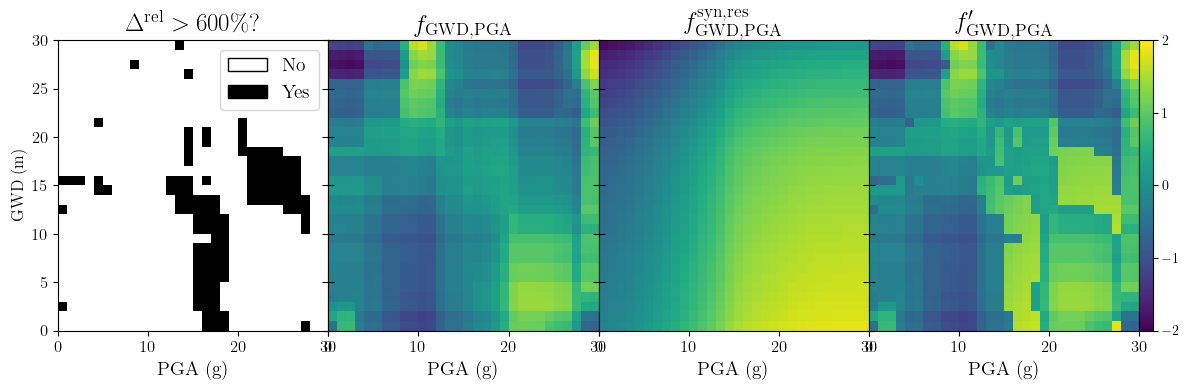

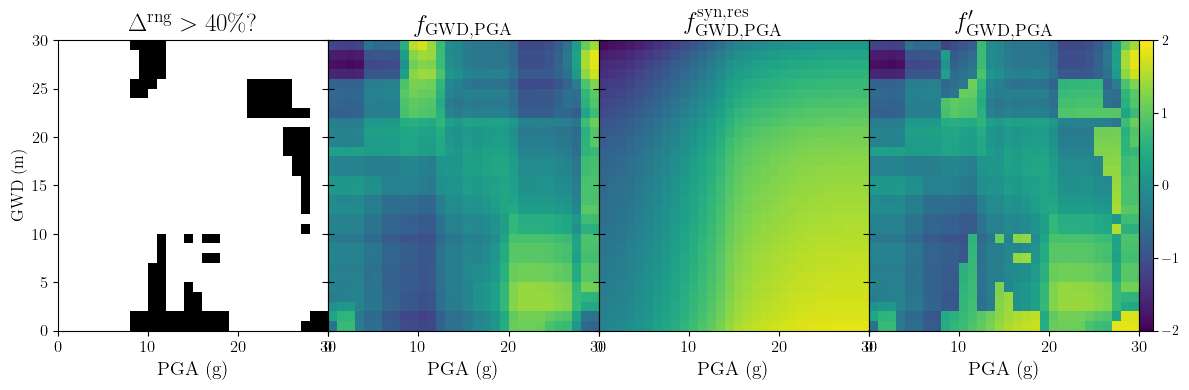

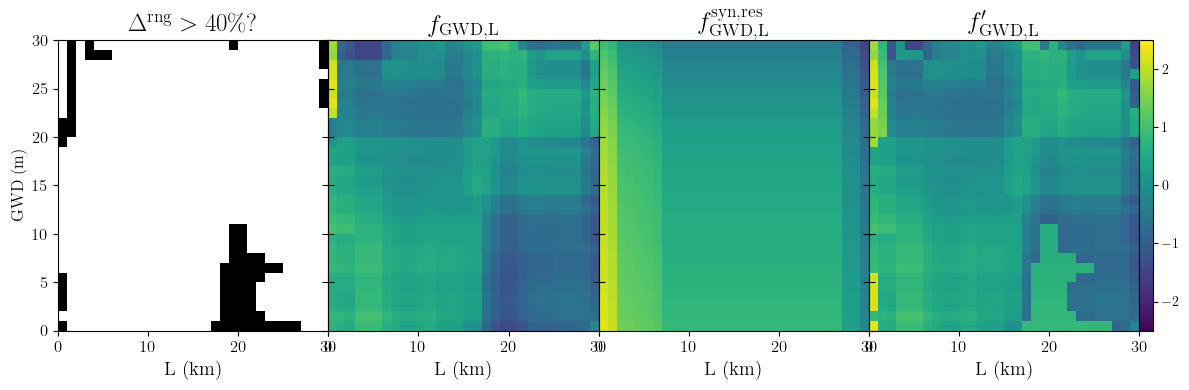

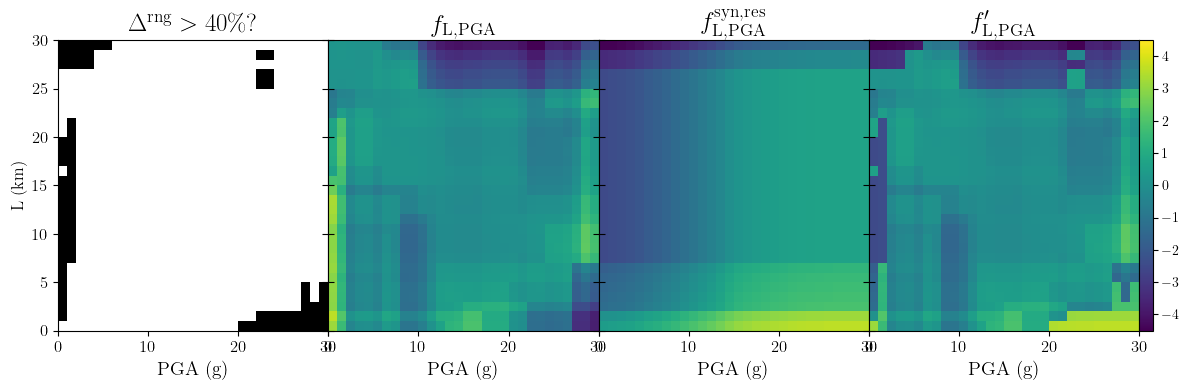

In [58]:
new_gwd_pga, fig = mask_map_func(gwd_pga_map,gwd_pga_edges,gwd_pga_index, threshold=6, check='rel', legend_loc='upper right')
fig.savefig(f'{fig_path}/modify-gwd-pga-rel.png', dpi=300)
new_gwd_pga, fig = mask_map_func(gwd_pga_map,gwd_pga_edges,gwd_pga_index, threshold=0.40)
fig.savefig(f'{fig_path}/modify-gwd-pga-abs.png', dpi=300)
new_gwd_l, fig = mask_map_func(gwd_l_map,gwd_l_edges,gwd_l_index, vmin=-2.5, vmax=2.5, threshold=0.40)
fig.savefig(f'{fig_path}/modify-gwd-l-abs.png', dpi=300)
new_l_pga, fig = mask_map_func(l_pga_map,l_pga_edges,l_pga_index, vmin=-4.5, vmax=4.5, threshold=0.40)
fig.savefig(f'{fig_path}/modify-l-pga-abs.png', dpi=300)

### Replace map

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.809,0.776,0.759,0.767,0.888
Valid,0.769,0.743,0.690,0.715,0.832
Test,0.755,0.732,0.696,0.714,0.832


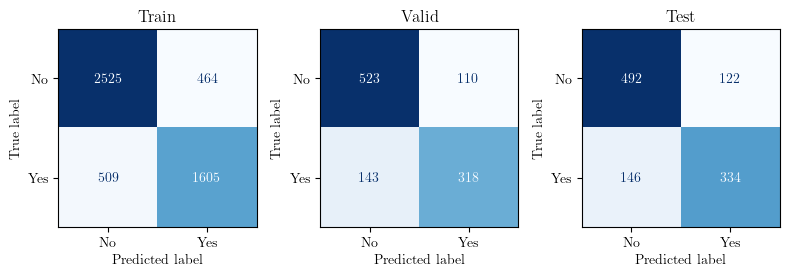

In [ ]:
# replace interaction map with rescaled synthetic map
ebm.term_scores_[gwd_pga_index] = new_gwd_pga
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test], valid=False)

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.800,0.755,0.765,0.760,0.877
Valid,0.766,0.731,0.703,0.717,0.826
Test,0.754,0.723,0.713,0.718,0.831


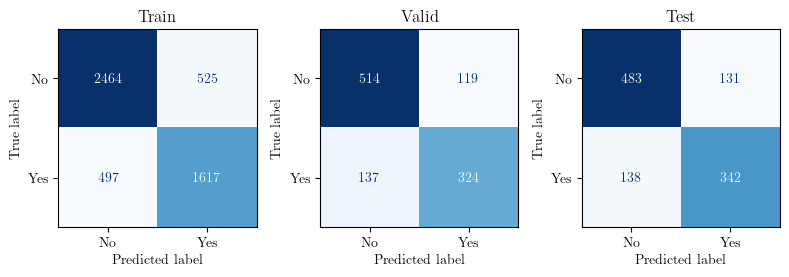

In [60]:
ebm.term_scores_[gwd_l_index] = new_gwd_l
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.788,0.742,0.747,0.745,0.829
Valid,0.760,0.722,0.698,0.710,0.800
Test,0.750,0.719,0.708,0.714,0.800


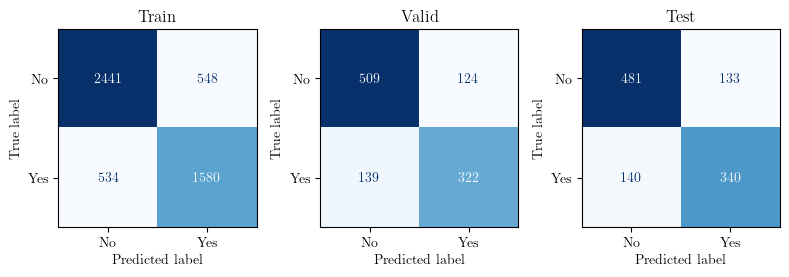

In [61]:
ebm.term_scores_[l_pga_index] = new_l_pga
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

In [62]:
# save modified score terms
modified_score = [score for score in ebm.term_scores_]

,Acc,Precision,Recall,F1,ROC-AUC
Train,0.883,0.886,0.824,0.853,0.951
Valid,0.804,0.800,0.714,0.755,0.874
Test,0.799,0.816,0.700,0.753,0.878


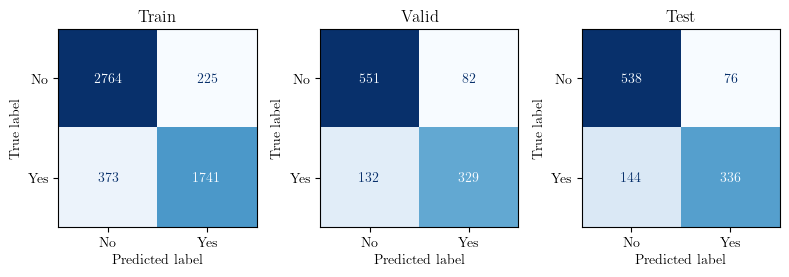

In [ ]:
# restore the all original score terms and show the report
restore_ebm(old_score)
score_report(ebm, X=[X_train,X_valid,X_test], y=[y_train,y_valid,y_test])

### SHAP Explanation

Here we are going to see what it will look like if we use SHAP to explain RF, XGB, Original EBM, and the modified EBM. 

In [64]:
import shap

/Users/clawsy/Documents/GitHub/ebm/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [91]:
# compute SHAP values
xgb_explainer = shap.Explainer(best_xgb, X_train)
xgb_shap_values = xgb_explainer(X_train)

rf_explainer = shap.Explainer(best_rf, X_train)
rf_shap_values = rf_explainer(X_train)


 99%|===================| 10140/10206 [00:39<00:00]       

In [92]:
restore_ebm(old_score)
old_ebm_explainer = shap.Explainer(ebm.predict, X_train) # pass ebm.predict function
old_ebm_shap_values = old_ebm_explainer(X_train)

restore_ebm(modified_score)
modified_ebm_explainer = shap.Explainer(ebm.predict, X_train)
modified_ebm_shap_values = modified_ebm_explainer(X_train)

In [93]:
# rename features without unit behind it for better visualization
feature_name = ['GWD', 'Elevation', 'L', 'Slope', 'PGA']
xgb_shap_values.feature_names = feature_name
rf_shap_values.feature_names = feature_name
old_ebm_shap_values.feature_names = feature_name
modified_ebm_shap_values.feature_names = feature_name

In [94]:
# By default, SHAP will order features by their importance, 
# but it is hard to compare the same feature across different models if the order is different.
# So we specify the order of features to be the same as the original feature order in the dataset.
order = [0 ,2, 4, 1, 3] # Fixed order = ['GWD', 'L', 'PGA', 'Elevation', 'Slope']
marker_size = 5

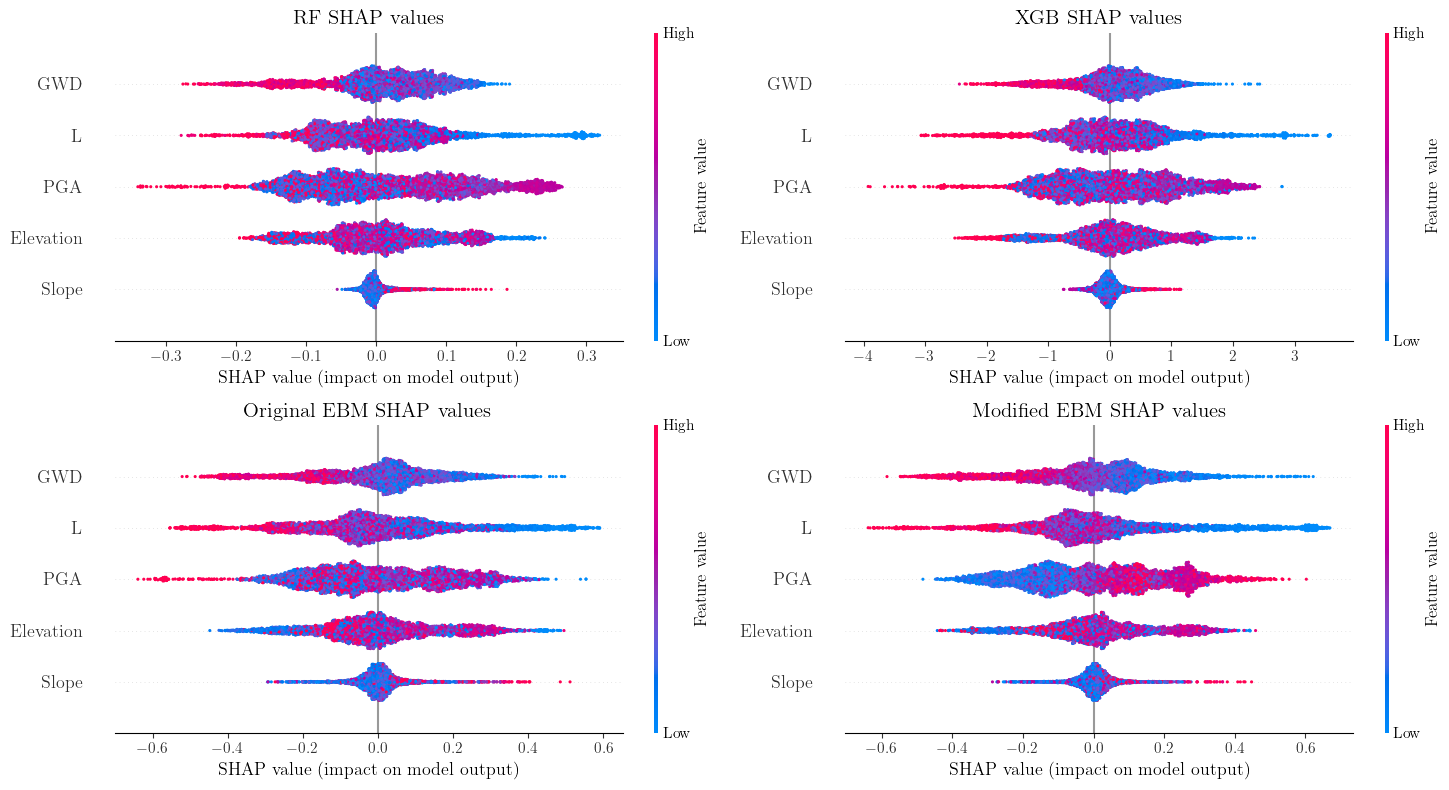

In [95]:
fig, ax = plt.subplots(2,2, figsize=(15, 8))
shap.plots.beeswarm(rf_shap_values[:,:,1], ax=ax[0,0], plot_size=None, show=False, order=order, s=marker_size)
shap.plots.beeswarm(xgb_shap_values, ax=ax[0,1],plot_size=None, show=False, order=order, s=marker_size)
shap.plots.beeswarm(old_ebm_shap_values, ax=ax[1,0],plot_size=None, show=False, order=order, s=marker_size)
shap.plots.beeswarm(modified_ebm_shap_values, ax=ax[1,1],plot_size=None, show=False, order=order, s=marker_size)
ax[0,0].set_title('RF SHAP values', fontsize=15)
ax[0,1].set_title('XGB SHAP values', fontsize=15)
ax[1,0].set_title('Original EBM SHAP values', fontsize=15)
ax[1,1].set_title('Modified EBM SHAP values', fontsize=15)
plt.tight_layout()
plt.savefig(f'{fig_path}/shap_beeswarm.png', dpi=300)

### Output Prediction

In [67]:
# combine id_test, X_test, y_test
saved_df = pd.concat([id_test, X_test, y_test], axis=1)
restore_ebm(old_score)
print('Original model', ebm.score(X_test, y_test))
saved_df['orig']=ebm.predict_proba(X_test)[:,1]
restore_ebm(modified_score)
print('Domain-Informed model', ebm.score(X_test, y_test))
saved_df['di']=ebm.predict_proba(X_test)[:,1]

# save the dataframe
saved_df.to_csv(f'{data_path}/ebm_prediction.csv', index=False)

Original model 0.7989031078610603
Domain-Informed model 0.7504570383912249


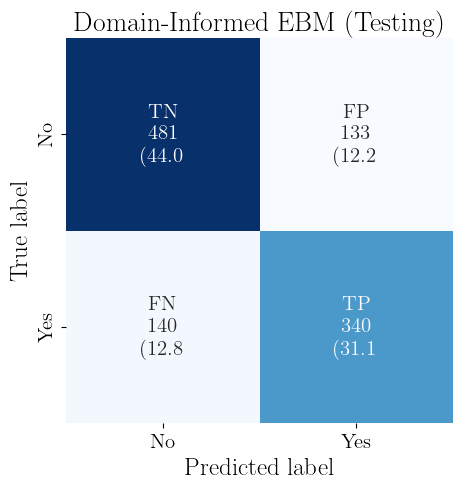

In [96]:
from sklearn.metrics import confusion_matrix
restore_ebm(modified_score)
# restore_ebm(old_score)
temp = pd.DataFrame(confusion_matrix(y_test,ebm.predict(X_test)), index=['No','Yes'], columns=['No','Yes'])
plt.figure(figsize = (5,5))
annots = [
    [f'TN\n{temp.iloc[0,0]}\n({temp.iloc[0,0]/len(y_test)*100:.1f}%)',f'FP\n{temp.iloc[0,1]}\n({temp.iloc[0,1]/len(y_test)*100:.1f}%)'],
    [f'FN\n{temp.iloc[1,0]}\n({temp.iloc[1,0]/len(y_test)*100:.1f}%)',f'TP\n{temp.iloc[1,1]}\n({temp.iloc[1,1]/len(y_test)*100:.1f}%)']]
ax = sns.heatmap(temp, annot=annots, fmt='s', annot_kws={'fontsize':15}, cmap='Blues',cbar=False,)
ax.set_xlabel("Predicted label",fontsize=18)
ax.set_ylabel("True label",fontsize=18)
ax.set_xticklabels(['No','Yes'],fontsize=15)
ax.set_yticklabels(['No','Yes'],fontsize=15)
ax.set_title("Domain-Informed EBM (Testing)",fontsize=20)
plt.savefig(f'{fig_path}/confusion_di.png', dpi=300)

## Global explanation comparison

In [97]:
restore_ebm(modified_score)
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/13681950000/ -->

In [99]:
dataset = X_test
ans = y_test

restore_ebm(old_score)
old_pred = ebm.predict(dataset)
restore_ebm(modified_score)
new_pred = ebm.predict(dataset)
# cases improved
fp_tn = (ans==0) & (old_pred==1) & (new_pred==0)
fn_tp = (ans==1) & (old_pred==0) & (new_pred==1)
print('cases improved:')
print(f'FN to TP: {sum(fn_tp)}')
print(f'FP to TN: {sum(fp_tn)}')
# cases getting worse
tp_fn = (ans==1) & (old_pred==1) & (new_pred==0)
tn_fp = (ans==0) & (old_pred==0) & (new_pred==1)
print('cases degrade')
print(f'TP to FN: {sum(tp_fn)}')
print(f'TN to FP: {sum(tn_fp)}')
# cases remain correct
tp_tp = (ans==1) & (old_pred==1) & (new_pred==1)
tn_tn = (ans==0) & (old_pred==0) & (new_pred==0)
print('cases remain correct')
print(f'remain TP: {sum(tp_tp)}')
print(f'remain TN: {sum(tn_tn)}')
# cases remain incorrect
fp_fp = (ans==0) & (old_pred==1) & (new_pred==1)
fn_fn = (ans==1) & (old_pred==0) & (new_pred==0)
print('cases remain incorrect')
print(f'remain FP: {sum(fp_fp)}')
print(f'remain FN: {sum(fn_fn)}')

cases improved:
FN to TP: 35
FP to TN: 21
cases degrade
TP to FN: 31
TN to FP: 78
cases remain correct
remain TP: 305
remain TN: 460
cases remain incorrect
remain FP: 55
remain FN: 109


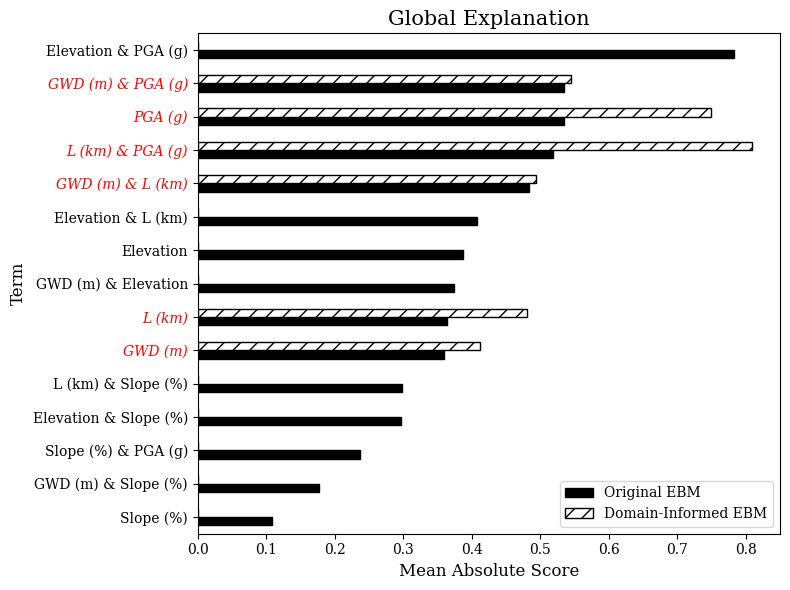

In [101]:
plt.rcParams.update({
    "text.usetex": False
})

fig, ax = plt.subplots(figsize=(8,6))
restore_ebm(old_score)
old_contrib = np.copy(ebm.term_importances())
restore_ebm(modified_score)
new_contrib = np.copy(ebm.term_importances())
changed_index = [0,2,4,6,8,13]
new_contrib[~np.isin(np.arange(15),changed_index)] = np.nan #only show the changed feature contrib
my_colors = np.array(['k']*15)
my_colors[changed_index] = 'r'
term = [name for name in ebm.term_names_]
df_contrib = pd.DataFrame(data={'term':term, 'Original EBM':old_contrib, 'Domain-Informed EBM':new_contrib, 'label_color':my_colors})
df_contrib.sort_values(by=['Original EBM'], inplace=True)
df_contrib.plot.barh(x='term', y=['Original EBM', 'Domain-Informed EBM'],color={'Original EBM':'k','Domain-Informed EBM':'w'},hatch="//",edgecolor='k', rot=0, ax=ax)
for ticklabel, tickcolor in zip(plt.gca().get_yticklabels(), df_contrib['label_color']):
  ticklabel.set_color(tickcolor)
  if tickcolor != 'k':
    ticklabel.set_fontstyle('italic')
plt.ylabel('Term',fontsize=12)
plt.xlabel('Mean Absolute Score',fontsize=12)
plt.title('Global Explanation', fontsize=15)
plt.tight_layout()
plt.savefig(f'{fig_path}/global_bar_comparison.png', dpi=200)

In [102]:
# sort by Domain-informed EBM scores
df_contrib.sort_values(by=['Domain-Informed EBM'], inplace=True)
# replace nan with original EBM score
df_contrib.iloc[6:,2] = df_contrib.iloc[6:,1]

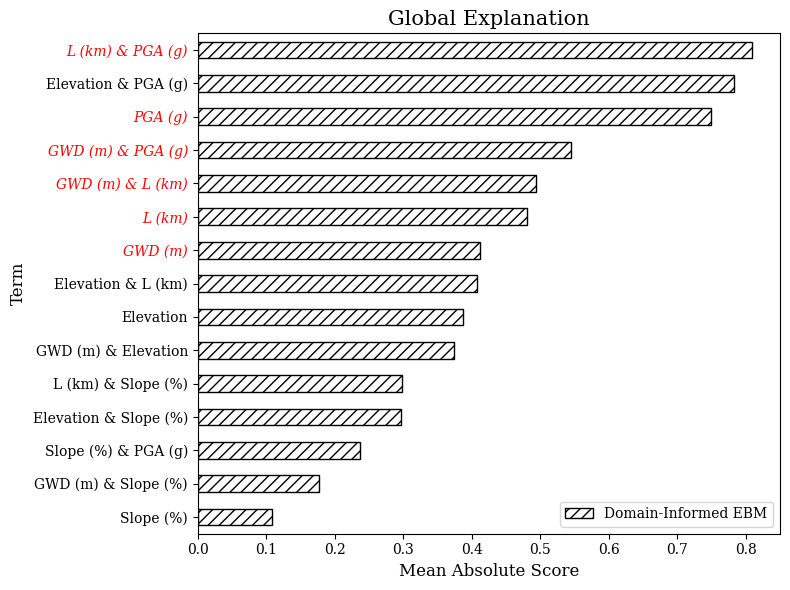

In [103]:
fig, ax = plt.subplots(figsize=(8,6))
# sort by Domain-informed EBM scores again
df_contrib.sort_values(by=['Domain-Informed EBM'], inplace=True)
df_contrib.plot.barh(x='term', y=['Domain-Informed EBM'],color={'Domain-Informed EBM':'w'},hatch="///",edgecolor='k', rot=0, ax=ax)
for ticklabel, tickcolor in zip(plt.gca().get_yticklabels(), df_contrib['label_color']):
  ticklabel.set_color(tickcolor)
  if tickcolor != 'k':
    ticklabel.set_fontstyle('italic')
plt.ylabel('Term',fontsize=12)
plt.xlabel('Mean Absolute Score',fontsize=12)
plt.title('Global Explanation', fontsize=15)
plt.tight_layout()
plt.savefig(f'{fig_path}/global_bar_di_only.png', dpi=200)

### Local Comparison

In [104]:
def local_compare(data, old_score, new_score=None, title=None, sorted=True, xlim=None):
    fig, ax = plt.subplots(figsize=(8,6))
    restore_ebm(old_score)
    old_contrib = np.mean(ebm.eval_terms(data), axis=0).reshape(-1)
    if data.shape[0] == 1:
        print(f'Old proba: {(ebm.predict_proba(data)[0][1]):.2f}')
    if new_score:
        restore_ebm(new_score)
        new_contrib = np.mean(ebm.eval_terms(data), axis=0).reshape(-1)
        new_contrib[~np.isin(np.arange(15),changed_index)] = np.nan #only show the changed feature contrib
        if data.shape[0] == 1:
            print(f'New proba: {(ebm.predict_proba([data])[0][1]):.2f}')
    abs_value = abs(old_contrib)
    #term = [name for name in ebm.term_names_]
    term = ['GWD', 'Elevation', 'L', 'Slope','PGA','GWD & Elevation','GWD & L','GWD & Slope','GWD & PGA','Elevation & L','Elevation & Slope','Elevation & PGA','L & Slope','L & PGA','Slope & PGA']
    my_colors = ['k','k','k','k','k','k','k','k','k','k','k','k','k','k','k']

    for num in range(5):
        # label the feature value
        term[num] += f'    [{np.mean(data,axis=0)[num]:.2f}]'
    df_contrib = pd.DataFrame(data={'term':term, 'Original model':old_contrib,
                                    'old abs value':abs_value, 'color':my_colors})
    if new_score:
        # print(new_contrib)
        df_contrib['Domain-Informed model']=new_contrib
        df_contrib['color'] = ['r','k','r','k','r','k','r','k','r','k','k','k','k','r','k']

    if sorted:
        # sort order based on old value
        df_contrib.sort_values('old abs value',inplace=True)

    if new_score:
        df_contrib.plot.barh(x='term', y=['Original model', 'Domain-Informed model'],color={'Original model':'k','Domain-Informed model':'w'},hatch="//",edgecolor='k', rot=0, ax=ax)
    else:
        bar_color = ['mediumseagreen' if value < 0 else 'orangered' for value in df_contrib['Original model'].values]
        df_contrib.plot.barh(x='term', y='Original model',color=bar_color,edgecolor='k', rot=0, ax=ax)


    ax.axvline(0,c='k')
    ax.set_xlabel('Score', fontsize=15)
    ax.set_ylabel('Term', fontsize=15)
    ax.set_title(title,fontsize=18)
    plt.yticks(fontsize=15)
    plt.xticks(fontsize=15)
    plt.grid(which='both',axis='x')
    for ticklabel, tickcolor in zip(plt.gca().get_yticklabels(), df_contrib['color']):
        ticklabel.set_color(tickcolor)
        if tickcolor != 'k':
            ticklabel.set_fontstyle('italic')
    ''' for ticklabel, tickcolor in zip(plt.gca().get_yticklabels(), df_contrib.color):
        ticklabel.set_color(tickcolor)'''
    if xlim:
        ax.set_xlim(xlim)
    if new_score is None:
        for rect, label in zip(ax.patches, df_contrib['Original model']):
            height = rect.get_height()
            width = rect.get_width()
            ax.text(
                np.clip(width, a_min=0.05, a_max=None) + 0.5*height, rect.get_y(), np.round(label,2), ha="center", va="bottom"
            )
        ax.get_legend().remove()
    plt.tight_layout()
    return ax

## Local explanation

Old proba: 0.41


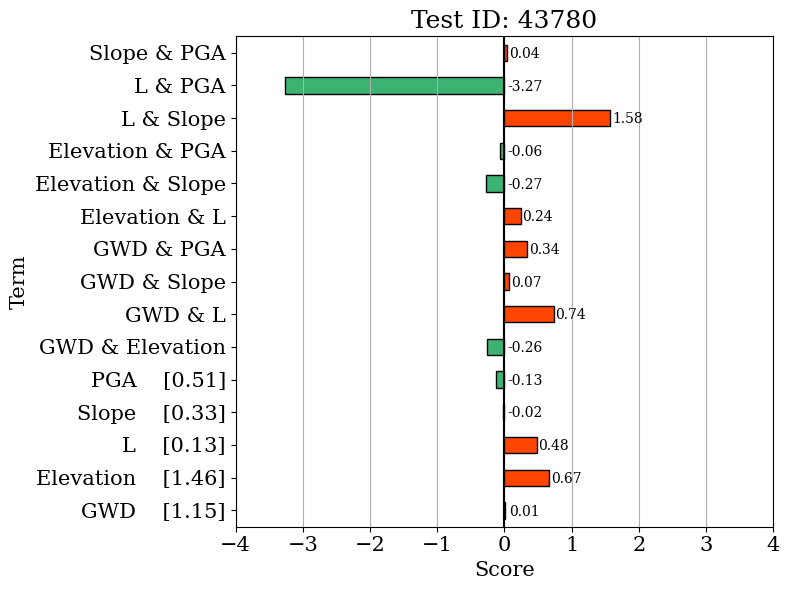

In [105]:
id = 43780
data = X_test[id_test == id].values
ax = local_compare(data, old_score, title=f'Test ID: {id}', sorted=False, xlim=(-4,4))
plt.savefig(f'{fig_path}/local_example.png',dpi=300)

### check with ID

Lateral Spreading: [False]
Old proba: 0.17
New proba: 1.00


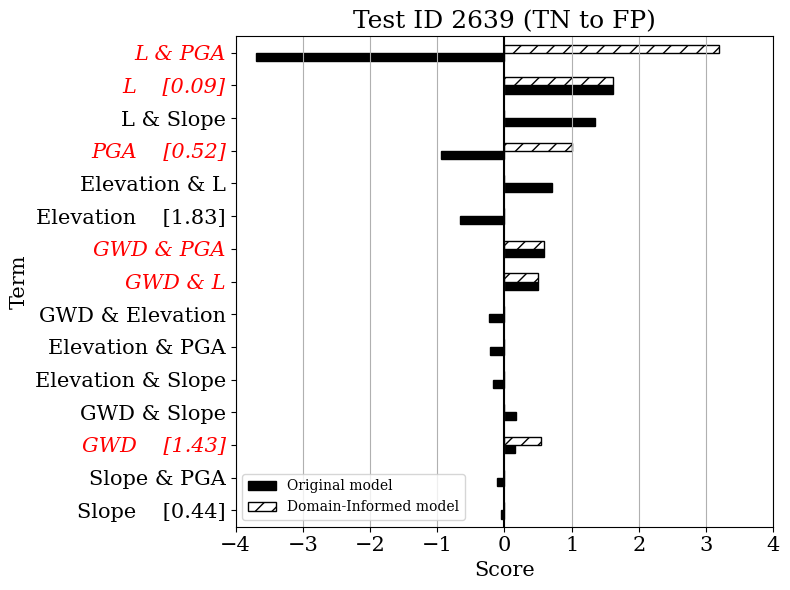

In [107]:
#17868, 25187, 344, 43424
# 43424 low PGA, high L, TP to FN
# 15574 low PGA, high L, FP to TN
# 17409 high PGA, medium GWD, FN to TP
# 2639 high PGA, low GWD, low L, TN to FP
# 4590 low GWD
id = 2639
data = X_test[id_test == id].values
print('Lateral Spreading:', y_test[id_test==id].values)
ax = local_compare(data, old_score, modified_score, title=f'Test ID {id} (TN to FP)', sorted=True, xlim=(-4,4))
plt.savefig(f'{fig_path}/id_{id}.png',dpi=300)